In [1]:
# 세팅
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
# 파일 선택
my_filepath = "/kaggle/input/datasets/paresh2047/uci-semcom/uci-secom.csv"
my_data = pd.read_csv(my_filepath, parse_dates=['Time'])
my_data.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


/tmp/ipykernel_17/4053111649.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=null_top50.index, y=null_top50.values, palette='viridis')


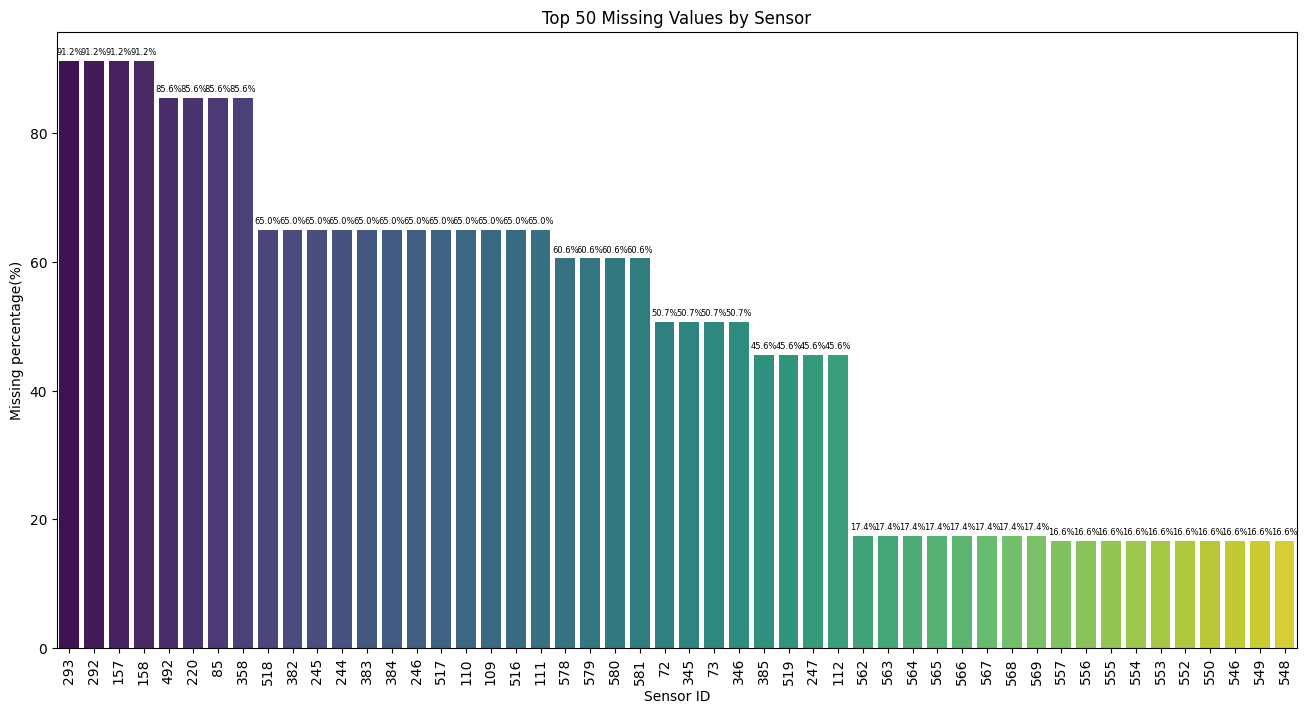

In [3]:
# 그래프 그리기(결측치 비율 top50 columns를 bar plot으로 시각화)

# secom dataset의 결측치의 비율을 "null_counts" Series로 저장
null_percent = my_data.isnull().mean()*100
# 상위 50개의 데이터만 추출
null_top50 = null_percent.sort_values(ascending=False).head(50)

plt.figure(figsize=(16,8))

# 막대그래프 작성
ax = sns.barplot(x=null_top50.index, y=null_top50.values, palette='viridis')

# 각 막대의 위에 값 레이블 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=6)
"""
ax.containers: 막대그래프 지칭
fmt='%.1f%%': "%.1f"(소수점 첫째까지 표시), "%%"(뒤에 % 붙임)
padding: 그래프와 간격 띄우기
"""

plt.title("Top 50 Missing Values by Sensor")
plt.xlabel("Sensor ID")
plt.ylabel("Missing percentage(%)")
# x축 눈금의 값을 반시계 방향으로 90도 회전
plt.xticks(rotation=90)

plt.show()

In [4]:
# constant columns 제거
n_unique = my_data.nunique()
constant_cols = n_unique[n_unique <= 1].index

print(f"상수 열의 개수: {len(constant_cols)}")
print(f"상수 열 목록: {constant_cols.tolist()}")
""".tolist(): 판다스나 넘파이의 인덱스나 시리즈 객체를 파이썬 기본 리스트 형태로 변환"""

my_data_dropped1 = my_data.drop(columns=constant_cols)

print(f"제거된 상수 열 개수: {len(constant_cols)}")
print(f"원본 열 개수: {my_data.shape[1]}")
print(f"제거 후 열 개수: {my_data_dropped1.shape[1]}")

""".shape[?}: 0 -> 행이 개수, 1 -> 열의 개수"""

상수 열의 개수: 116
상수 열 목록: ['5', '13', '42', '49', '52', '69', '97', '141', '149', '178', '179', '186', '189', '190', '191', '192', '193', '194', '226', '229', '230', '231', '232', '233', '234', '235', '236', '237', '240', '241', '242', '243', '256', '257', '258', '259', '260', '261', '262', '263', '264', '265', '266', '276', '284', '313', '314', '315', '322', '325', '326', '327', '328', '329', '330', '364', '369', '370', '371', '372', '373', '374', '375', '378', '379', '380', '381', '394', '395', '396', '397', '398', '399', '400', '401', '402', '403', '404', '414', '422', '449', '450', '451', '458', '461', '462', '463', '464', '465', '466', '481', '498', '501', '502', '503', '504', '505', '506', '507', '508', '509', '512', '513', '514', '515', '528', '529', '530', '531', '532', '533', '534', '535', '536', '537', '538']
제거된 상수 열 개수: 116
원본 열 개수: 592
제거 후 열 개수: 476


'.shape[?}: 0 -> 행이 개수, 1 -> 열의 개수'

In [5]:
# 결측 여부와 불량률 간의 연관성 확인

# 불량률 평균을 구하기 위해 불량=1, 정상=0인 시리즈 생성
labels = (my_data['Pass/Fail'] == 1).astype(int)

# 결측치가 존재하는 열만 추출
null_cols = my_data_dropped1.columns[my_data_dropped1.isnull().any()]

# 각 열에서 결측 여부와 불량률 관계 분석
results = []

# 결측일때의 불량률과, 정상일때의 불량률 비교
for col in null_cols:
    # my_data_dropped1 중 결측치를 가지는 열의 각 행들을 1(결측), 0(정상)으로 나타내는 시리즈
    is_null = my_data_dropped1[col].isnull().astype(int)
    # is_null이 1(결측)인 행번호의 labels 값들의 평균을 반환
    fail_when_null = labels[is_null == 1].mean()
    # is_null이 0(정상)인 행번호의 labels 값들의 평균을 반환
    fail_when_not_null = labels[is_null == 0].mean()
    results.append({
        'column': col,
        'null_ratio': is_null.mean(),
        'fail_rate_when_null': fail_when_null,
        'fail_rate_when_not_null': fail_when_not_null,
        'diff': abs(fail_when_null - fail_when_not_null)
    })

result_df = pd.DataFrame(results).sort_values('diff', ascending=False)
print(result_df.head(20))

# diff가 상위인 행의 결츨비율 매우 작음 -> 결측 비율이 0.05 이상인 열들에 대해서 비교
meaningful = result_df[result_df['null_ratio'] >= 0.05].sort_values('diff', ascending=False)
print(f"해당 열 개수: {len(meaningful)}")
print(meaningful.head(20))

    column  null_ratio  fail_rate_when_null  fail_rate_when_not_null      diff
28      31    0.001276                  0.5                 0.065815  0.434185
24      27    0.001276                  0.5                 0.065815  0.434185
27      30    0.001276                  0.5                 0.065815  0.434185
26      29    0.001276                  0.5                 0.065815  0.434185
25      28    0.001276                  0.5                 0.065815  0.434185
22      25    0.001276                  0.5                 0.065815  0.434185
23      26    0.001276                  0.5                 0.065815  0.434185
21      24    0.001276                  0.5                 0.065815  0.434185
20      23    0.001276                  0.5                 0.065815  0.434185
321    435    0.001276                  0.5                 0.065815  0.434185
19      22    0.001276                  0.5                 0.065815  0.434185
18      21    0.001276                  0.5         

In [6]:
# 확인 결과, 유의미한 비율의 결측치를 갖는 열에서, diff가 매우 작게 나타나는 것을 볼때, 결측 유무가 불량과 거의 관계 없음을 알 수 있다.
# -> 45.6% 이상의 결측 비율을 갖는 열은 제거(45.6%에서 불연속 변곡 발생)
# -> 그 이하의 열은 대체: 중앙값을 대체하여, 데이터 왜곡(중앙값 스파이크, 가짜 상봉형)이 심하게 발생하는 문제가 있었으므로, 스케일링 후 KNN Imputer로 대체

In [7]:
# 오류 방지를 위해 결측칙 있는지 우선 확인
print(my_data_dropped1['Time'].isnull().sum())

0


In [8]:
# 결측치가 없으므로 숫자로 변환
my_data_dropped1['Time'] = my_data_dropped1['Time'].astype('int64')

In [9]:
# 이상치 가공 전, 이상치 diff 분석 / 이상치 자체가 불량 신호인지 확인하기 위함
outlier_results = []

for col in my_data_dropped1.select_dtypes(include='number').columns:
    Q1 = my_data_dropped1[col].quantile(0.25)
    Q3 = my_data_dropped1[col].quantile(0.75)
    IQR = Q3 - Q1
    is_outlier = ((my_data_dropped1[col] < Q1 - 1.5*IQR) | 
                  (my_data_dropped1[col] > Q3 + 1.5*IQR)).astype(int)
    
    fail_when_outlier = labels[is_outlier == 1].mean()
    fail_when_normal = labels[is_outlier == 0].mean()
    
    outlier_results.append({
        'column': col,
        'outlier_ratio': is_outlier.mean(),
        'fail_when_outlier': fail_when_outlier,
        'fail_when_normal': fail_when_normal,
        'diff': abs(fail_when_outlier - fail_when_normal)
    })

outlier_result_df = pd.DataFrame(outlier_results).sort_values('diff', ascending=False)
print(outlier_result_df.head(20))

        column  outlier_ratio  fail_when_outlier  fail_when_normal      diff
475  Pass/Fail       0.066369           1.000000          0.000000  1.000000
51          55       0.003191           0.400000          0.065301  0.334699
446        561       0.005743           0.333333          0.064827  0.268507
60          64       0.042119           0.287879          0.056629  0.231250
204        221       0.004467           0.285714          0.065385  0.220330
403        493       0.004467           0.285714          0.065385  0.220330
26          27       0.015316           0.250000          0.063513  0.186487
444        559       0.007658           0.250000          0.064952  0.185048
177        188       0.002553           0.250000          0.065899  0.184101
73          78       0.010849           0.235294          0.064516  0.170778
435        550       0.008296           0.230769          0.064994  0.165776
20          21       0.022974           0.222222          0.062704  0.159518

In [10]:
# Pass/Fail 열은 무시, diff의 최대가 0.33으로 꽤 연관성 있음.

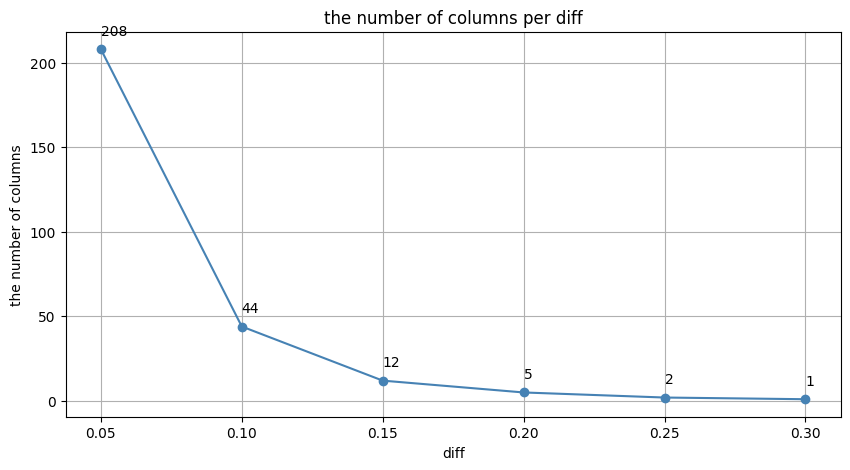

In [11]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
counts = [208, 44, 12, 5, 2, 1]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, counts, marker='o', color='steelblue')
plt.title("the number of columns per diff")
plt.xlabel("diff")
plt.ylabel("the number of columns")
for t, c in zip(thresholds, counts):
    plt.annotate(f'{c}', (t, c), textcoords="offset points", xytext=(0, 10))
plt.grid(True)
plt.show()

In [12]:
# 0.05와 0.10 사이에 더 자세한 추세 호가인 필요

diff 0.05 이상: 208개 열
diff 0.06 이상: 179개 열
diff 0.07 이상: 79개 열
diff 0.08 이상: 61개 열
diff 0.09 이상: 53개 열
diff 0.1 이상: 44개 열


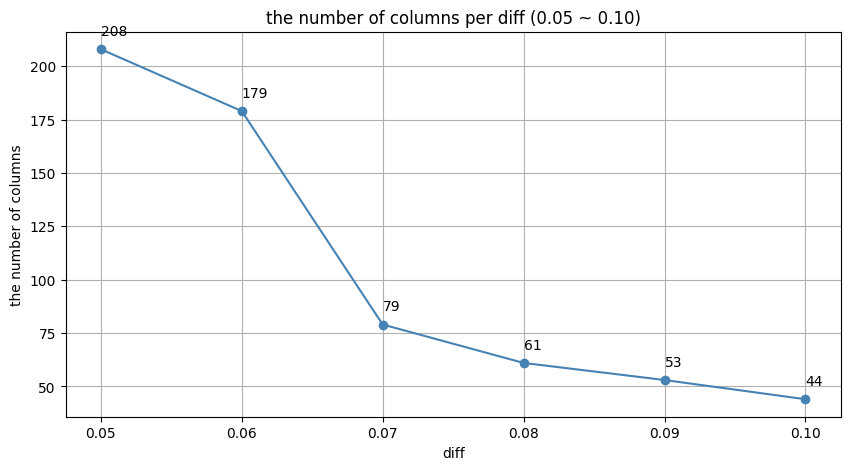

In [13]:
import numpy as np

thresholds_detail = [0.05, 0.06, 0.07, 0.08, 0.09, 0.10]
counts_detail = []

for t in thresholds_detail:
    count = len(outlier_result_df[
        (outlier_result_df['diff'] >= t) & 
        (outlier_result_df['column'] != 'Pass/Fail')
    ])
    counts_detail.append(count)
    print(f"diff {t} 이상: {count}개 열")

plt.figure(figsize=(10, 5))
plt.plot(thresholds_detail, counts_detail, marker='o', color='steelblue')
plt.title("the number of columns per diff (0.05 ~ 0.10)")
plt.xlabel("diff")
plt.ylabel("the number of columns")
for t, c in zip(thresholds_detail, counts_detail):
    plt.annotate(f'{c}', (t, c), textcoords="offset points", xytext=(0, 10))
plt.grid(True)
plt.show()

In [14]:
# 0.07은 elbow지점 -> 자연스러운 경계

In [15]:
# Flagging 대상 열 (0.07 기준 + 40, 129 수동 추가)
flagging_cols = outlier_result_df[
    (outlier_result_df['diff'] >= 0.07) & 
    (outlier_result_df['column'] != 'Pass/Fail')
]['column'].tolist()

flagging_cols += ['40', '129']
print(f"Flagging 대상 열 개수: {len(flagging_cols)}")

# Flagging 수행
before_cols = my_data_dropped1.shape[1]

for col in flagging_cols:
    Q1 = my_data_dropped1[col].quantile(0.25)
    Q3 = my_data_dropped1[col].quantile(0.75)
    IQR = Q3 - Q1
    my_data_dropped1[f'{col}_outlier_flag'] = (
        (my_data_dropped1[col] < Q1 - 1.5*IQR) |
        (my_data_dropped1[col] > Q3 + 1.5*IQR)
    ).astype(int)

print(f"Flagging 전 열 개수: {before_cols}")
print(f"Flagging 후 열 개수: {my_data_dropped1.shape[1]}")
print(f"추가된 열 개수: {my_data_dropped1.shape[1] - before_cols}")

Flagging 대상 열 개수: 81
Flagging 전 열 개수: 476
Flagging 후 열 개수: 557
추가된 열 개수: 81


In [16]:
# 데이터에 이상치가 있으므로, 이상치에 영향을 덜 받는 IQR 기반 RobustScaler 사용

In [17]:
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer

# 45.6% 이상 결측 열 제거
cols_to_drop = null_percent[null_percent >= 45.6].index
my_data_dropped2 = my_data_dropped1.drop(columns=cols_to_drop)
print(f"제거된 열 개수: {len(cols_to_drop)}")
print(f"제거 후 열 개수: {my_data_dropped2.shape[1]}")

# RobustScaler 적용
scaler = RobustScaler()
data_scaled = scaler.fit_transform(my_data_dropped2)

# KNN Imputer 적용
imputer = KNNImputer(n_neighbors=5)
data_imputed_scaled = imputer.fit_transform(data_scaled)

# 원래 범위 복원
final_data = pd.DataFrame(
    scaler.inverse_transform(data_imputed_scaled),
    columns=my_data_dropped2.columns
)

print(f"결측치 수: {final_data.isnull().sum().sum()}")

제거된 열 개수: 32
제거 후 열 개수: 525
결측치 수: 0


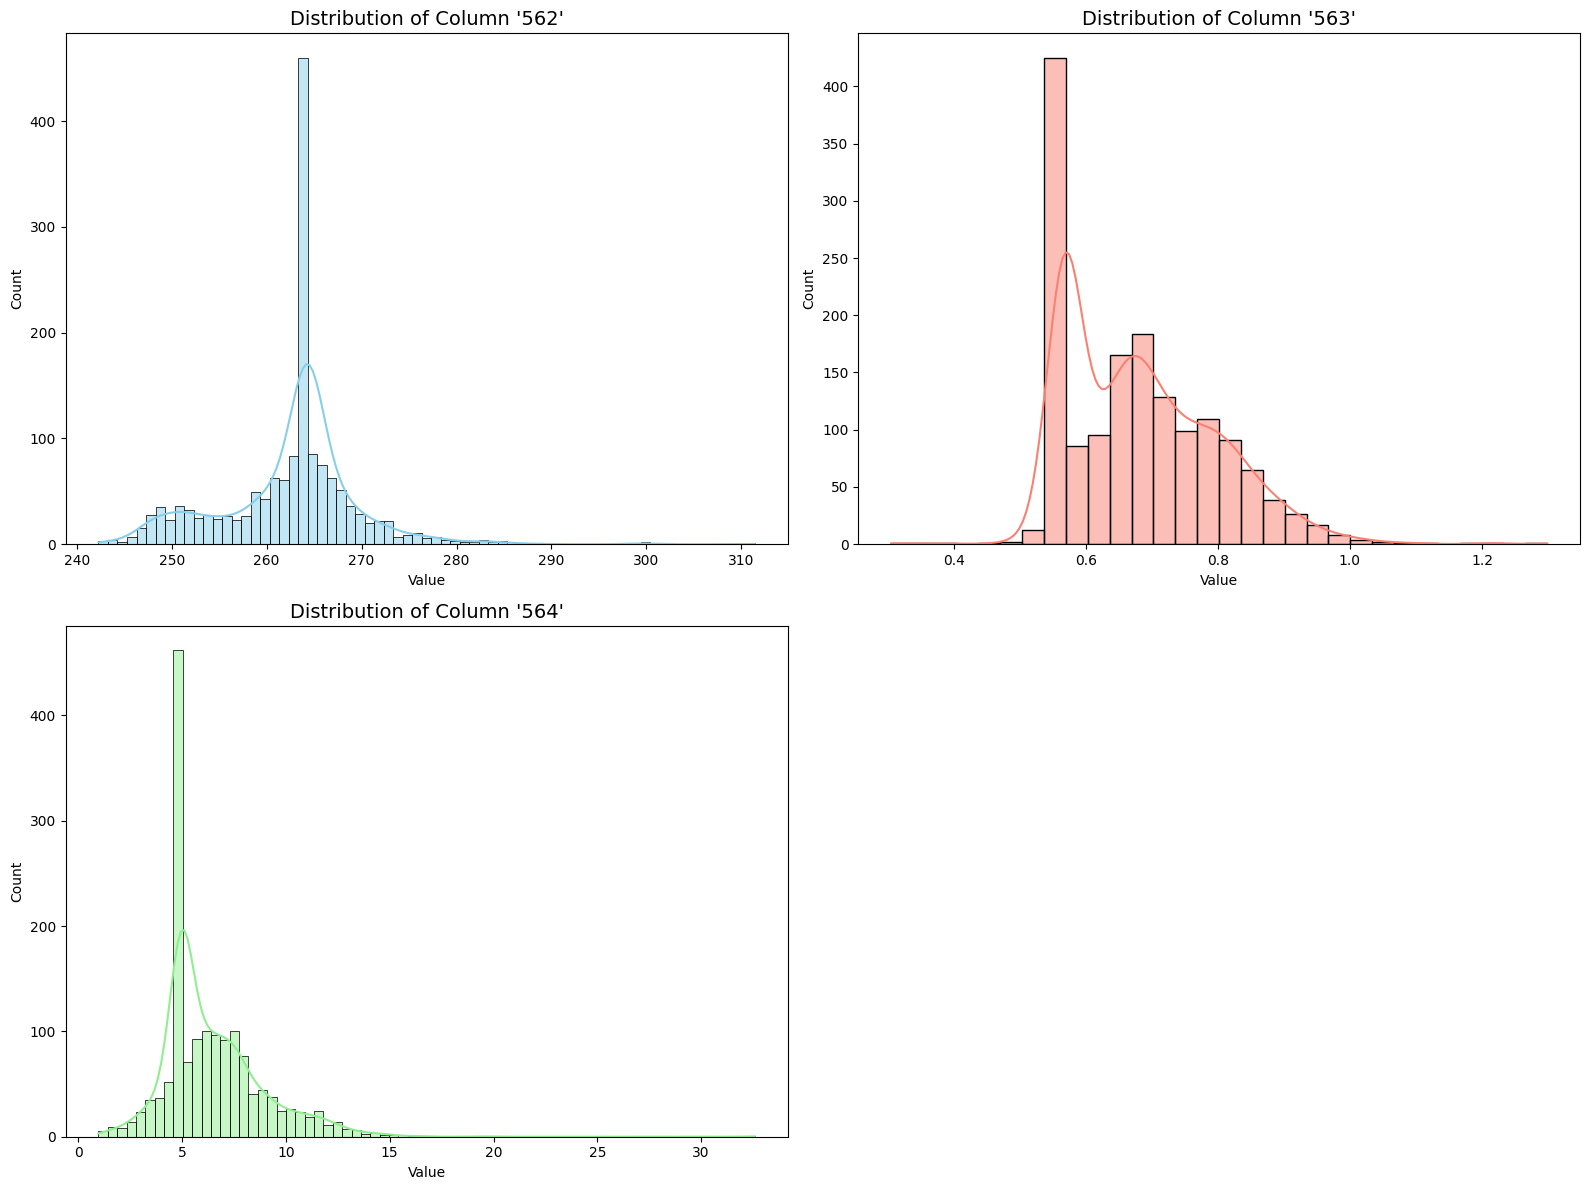

In [18]:
# 중앙값 처리 방식에서 문제를 보였던, 562, 563, 564 열 재확인
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
"""
fig: plot ouput 전체를 관리하는 객체
axes: 각각의 칸들을 답고 있는 리스트
plt.subplot(a, b): a -> 행 개수, b -> 열 개수  
"""
sns.histplot(final_data['562'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title("Distribution of Column '562'", fontsize=14)
axes[0, 0].set_xlabel("Value")

sns.histplot(final_data['563'], kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title("Distribution of Column '563'", fontsize=14)
axes[0, 1].set_xlabel("Value")

sns.histplot(final_data['564'], kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title("Distribution of Column '564'", fontsize=14)
axes[1, 0].set_xlabel("Value")

# 마지막 칸[1,1] 숨기기
axes[1, 1].axis('off')

# 그래프 간 간격 자동 조절
plt.tight_layout()
plt.show()

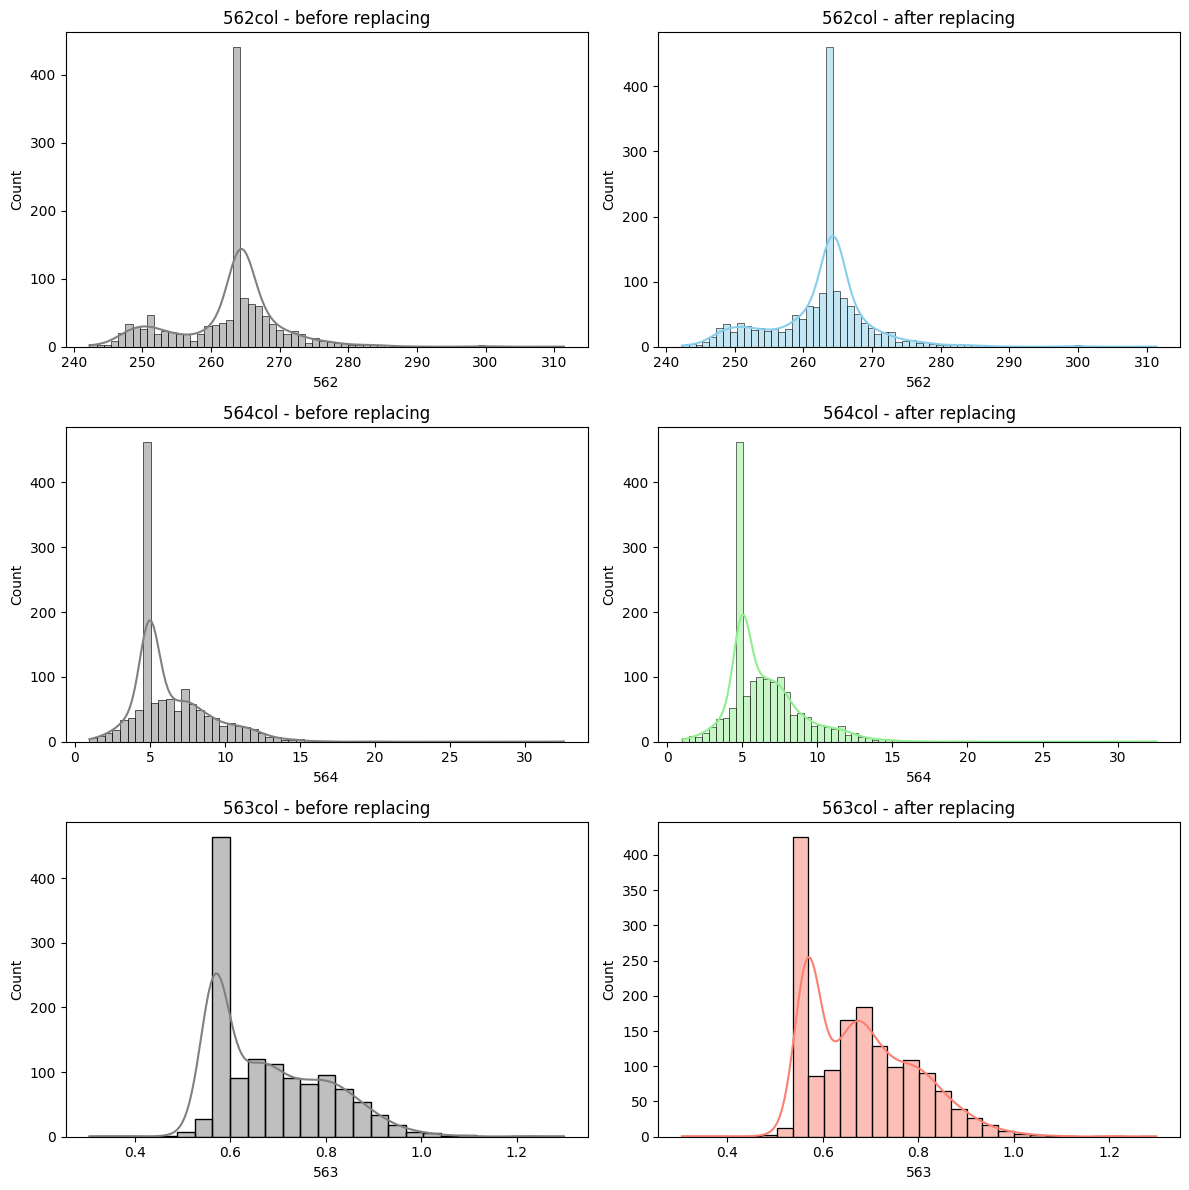

In [19]:
# 그래프의 형태의 원인이 대체인지 원본데이터 자체의 특성인지 확인 필요
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

# 562 대체 전(결측치 제외)
sns.histplot(my_data_dropped2['562'], kde=True, ax=axes[0,0], color='gray')
axes[0,0].set_title("562col - before replacing")
# 562 대체 후
sns.histplot(final_data['562'], kde=True, ax=axes[0,1], color='skyblue')
axes[0,1].set_title("562col - after replacing")

# 564 대체 전(결측치 제외)
sns.histplot(my_data_dropped2['564'], kde=True, ax=axes[1,0], color='gray')
axes[1,0].set_title("564col - before replacing")
# 564 대체 후
sns.histplot(final_data['564'], kde=True, ax=axes[1,1], color='lightgreen')
axes[1,1].set_title("564col - after replacing")

# 563 대체 전(결측치 제외)
sns.histplot(my_data_dropped2['563'], kde=True, ax=axes[2,0], color='gray')
axes[2,0].set_title("563col - before replacing")
# 563 대체 후
sns.histplot(final_data['563'], kde=True, ax=axes[2,1], color='salmon')
axes[2,1].set_title("563col - after replacing")

plt.tight_layout()
plt.show()

In [20]:
# 562, 564의 중앙값 스파이크는 원본 그래프 자체의 성질임 -> 대체가 잘 이뤄짐.
# 563은 현재 약한 가짜 쌍봉형 생성 -> 중앙값 대체보다 훨씬 약하며, 17.4% 대체를 고려할때 불가피하다고 판단.
# 즉, 현재 대체 선택지 중 KNN이 가장 나은 방식으로 고려.

In [21]:
# 각 열의 이상치 비율 확인 (IQR 방식, 급격하게 변하는 이상치의 영향을 피하기 위함)
outlier_ratio = {}

for col in final_data.columns:
    if col == 'Time' or 'outlier_flag' in col:
        continue
    Q1 = final_data[col].quantile(0.25)
    Q3 = final_data[col].quantile(0.75)
    IQR = Q3 - Q1
    range_lower = Q1 - 1.5 * IQR
    range_upper = Q3 + 1.5 * IQR
    outlier_ratio[col] = ((final_data[col] < range_lower) | (final_data[col] > range_upper)).mean() * 100

outlier_df = pd.Series(outlier_ratio).sort_values(ascending=False)
print(outlier_df.head(20))

31     22.654754
40     20.931717
544    15.252074
129    15.188258
312    14.932993
195    14.932993
177    14.677728
448    14.677728
467    13.975750
251    12.827058
59     12.699426
523    12.699426
23     12.444161
41     12.444161
116    12.252712
389    12.061264
562    11.933631
545    11.805999
335    11.550734
471    11.486918
dtype: float64


In [22]:
# 이상치가 꽤 높게 나타나는 것을 확인
# Time 열은 단순 시간 데이터로, 이상치 비율은 높게 나타나지만 무시해도 무관.
# 이상치와 불량률이 실제로 상관관계를 가지는지 확인 필요

/tmp/ipykernel_17/2727369150.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=final_data[col], ax=axes[i], palette='viridis')
/tmp/ipykernel_17/2727369150.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=final_data[col], ax=axes[i], palette='viridis')
/tmp/ipykernel_17/2727369150.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=final_data[col], ax=axes[i], palette='viridis')
/tmp/ipykernel_17/2727369150.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be 

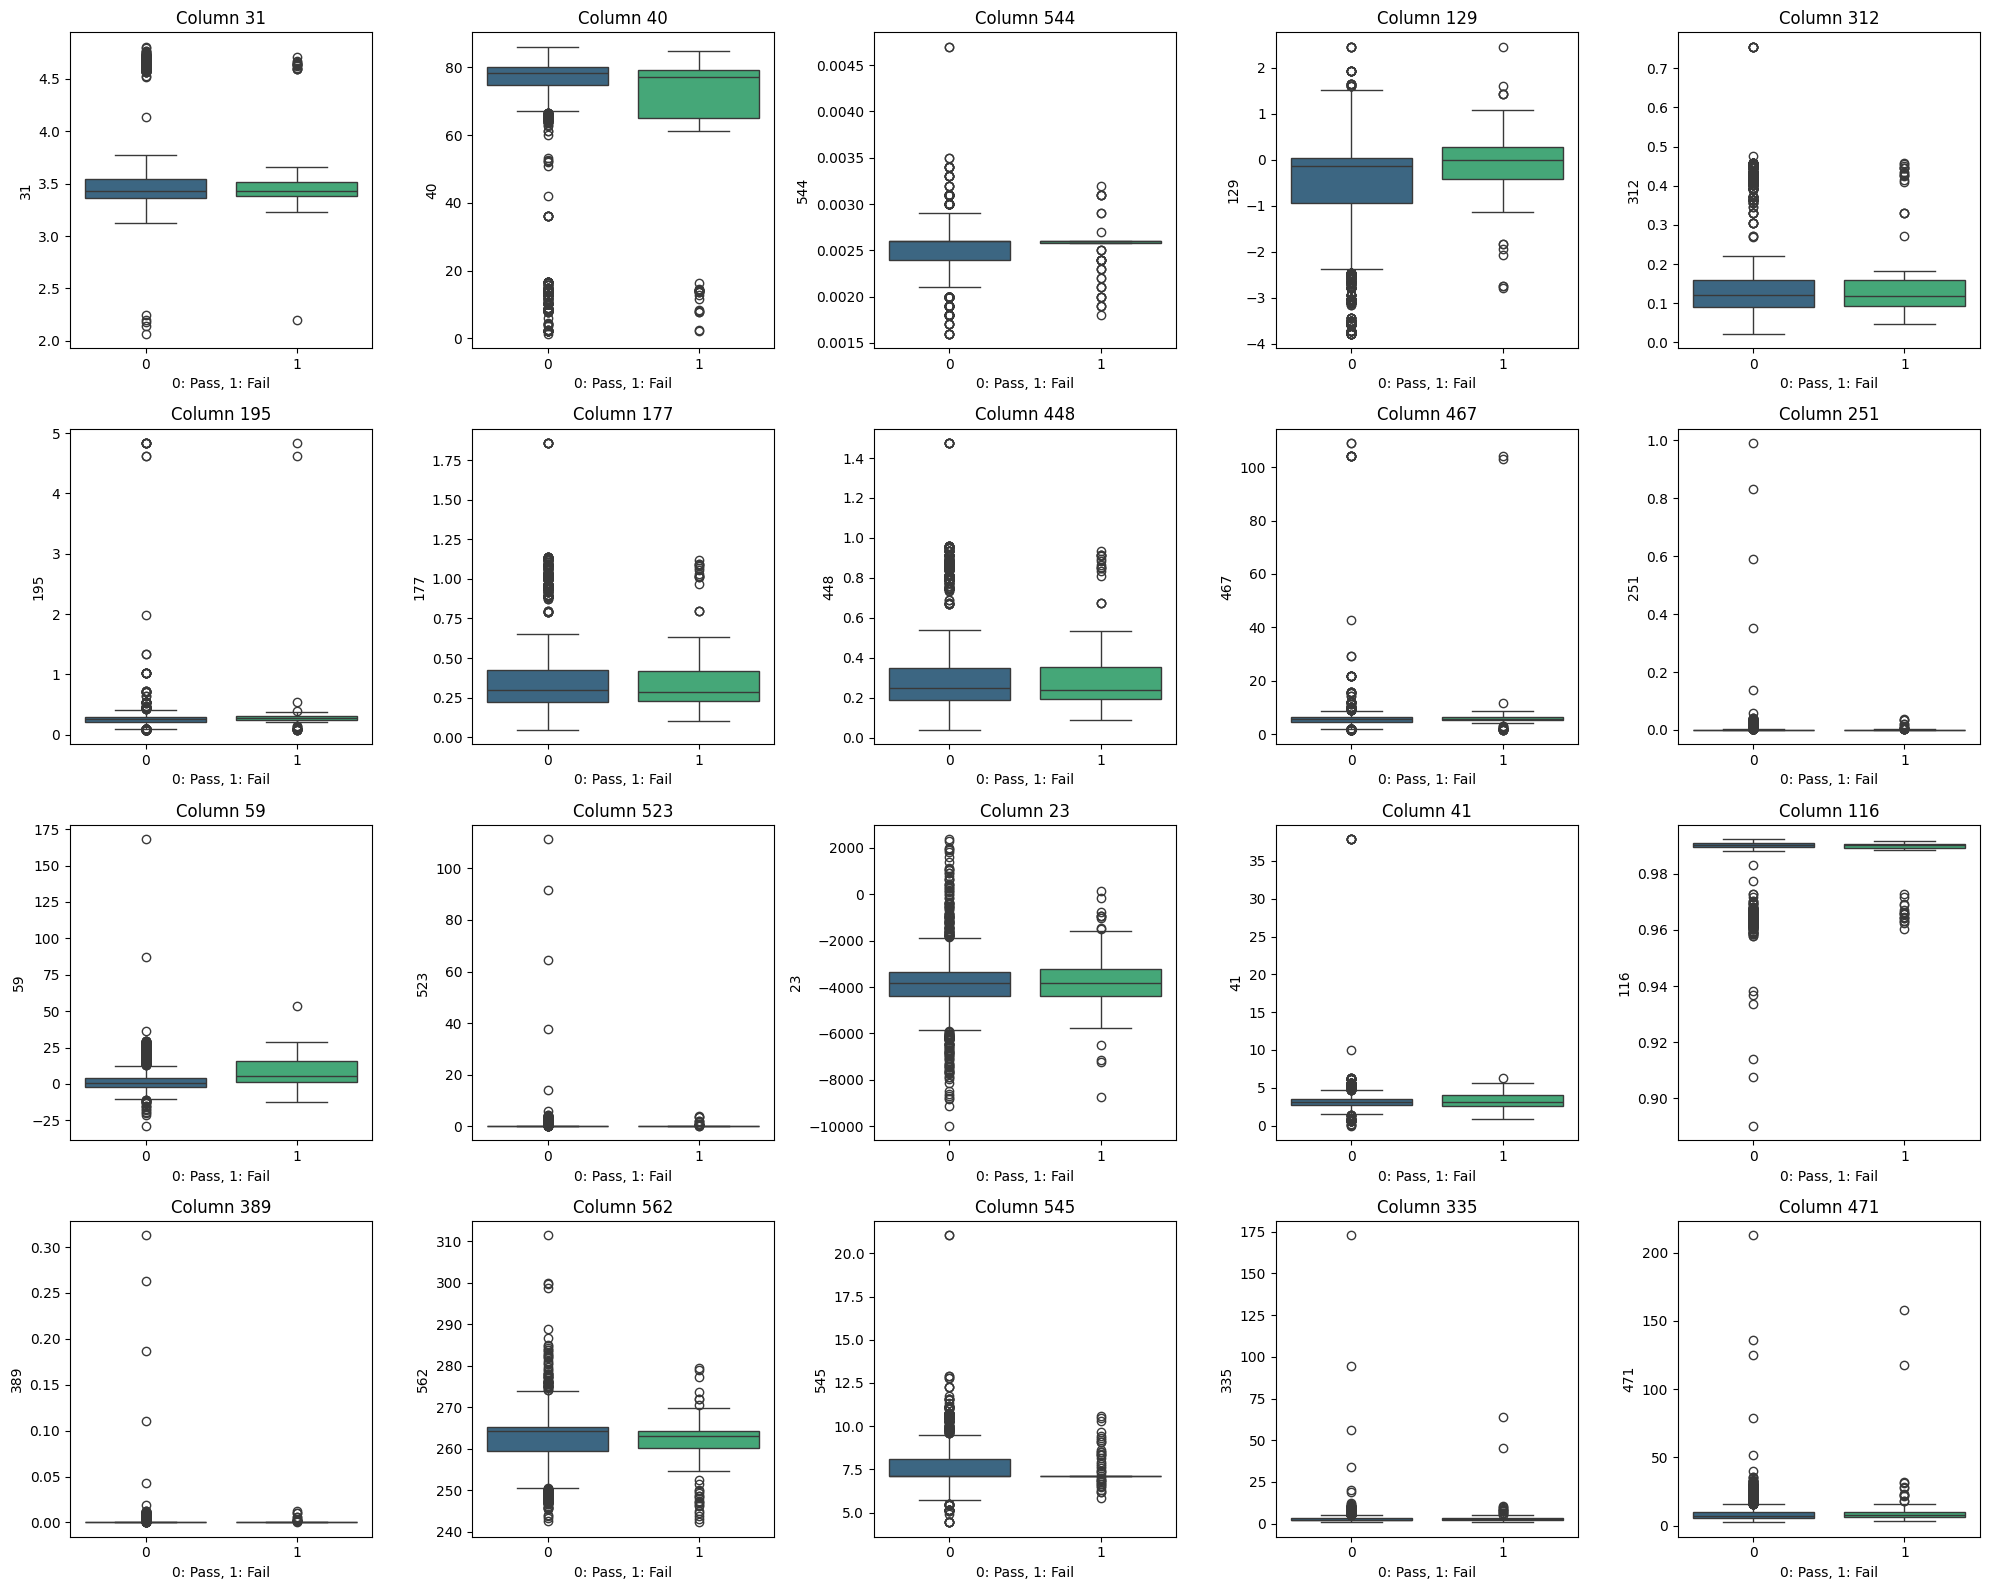

In [23]:
# 이상치 비율 상위 20개 열 확인
top_outlier_cols = outlier_df.head(20).index.tolist()
"""tolist() -> 시리즈를 기본 리스트로 변환"""

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()
"""flatten() -> 2차원 배열을 1차원으로 합침"""

for i, col in enumerate(top_outlier_cols):
    sns.boxplot(x=labels, y=final_data[col], ax=axes[i], palette='viridis')
    axes[i].set_title(f"Column {col}")
    axes[i].set_xlabel("0: Pass, 1: Fail")
"""enumerate() -> 반복문에서 인덱스와 값을 동시에 꺼내 사용 가능"""

plt.tight_layout()
plt.show()

In [24]:
print(flagging_cols)
print(outlier_result_df[outlier_result_df['column'].isin(['40', '129'])])

['55', '561', '64', '221', '493', '27', '559', '188', '78', '550', '21', '298', '65', '556', '26', '25', '38', '341', '148', '66', '324', '311', '477', '434', '63', '291', '343', '359', '510', '62', '205', '103', '59', '348', '437', '22', '165', '160', '299', '295', '553', '421', '7', '154', '346', '100', '584', '479', '345', '571', '300', '429', '156', '388', '427', '83', '76', '385', '431', '79', '163', '16', '77', '521', '331', '472', '361', '89', '252', '353', '317', '120', '249', '114', '387', '336', '213', '519', '247', '40', '129']
    column  outlier_ratio  fail_when_outlier  fail_when_normal      diff
123    129       0.151883           0.021008          0.074492  0.053484
39      40       0.210593           0.103030          0.056589  0.046442


In [25]:
# 0.10 기준에 40, 129열들은 Flagging이 안 됨.
# 기준을 0.05로 낮추기에는 208개로 너무 많음
# 확인 결과 Flagging 기준 0.07(elbow)로 낮춤 / 여전히 Flagging 안 되긴 함
# 40, 129열처럼 이상치가 많아 differ이 희석 됐을 가능성이 있는 다른 열도 조사 필요(수동 추가)

In [26]:
# 이상치 비율이 높으면서 박스플롯에서 차이가 보이는 열 확인
# 이상치 비율 10% 이상인 열 전체를 박스플롯으로 확인
high_outlier_cols = outlier_result_df[
    (outlier_result_df['outlier_ratio'] >= 0.10) &
    (outlier_result_df['column'] != 'Pass/Fail')
]['column'].tolist()

print(f"이상치 비율 10% 이상 열 개수: {len(high_outlier_cols)}")

이상치 비율 10% 이상 열 개수: 24


/tmp/ipykernel_17/3327512569.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=my_data_dropped1[col], ax=axes[i], palette='viridis')
/tmp/ipykernel_17/3327512569.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=my_data_dropped1[col], ax=axes[i], palette='viridis')
/tmp/ipykernel_17/3327512569.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=my_data_dropped1[col], ax=axes[i], palette='viridis')
/tmp/ipykernel_17/3327512569.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecate

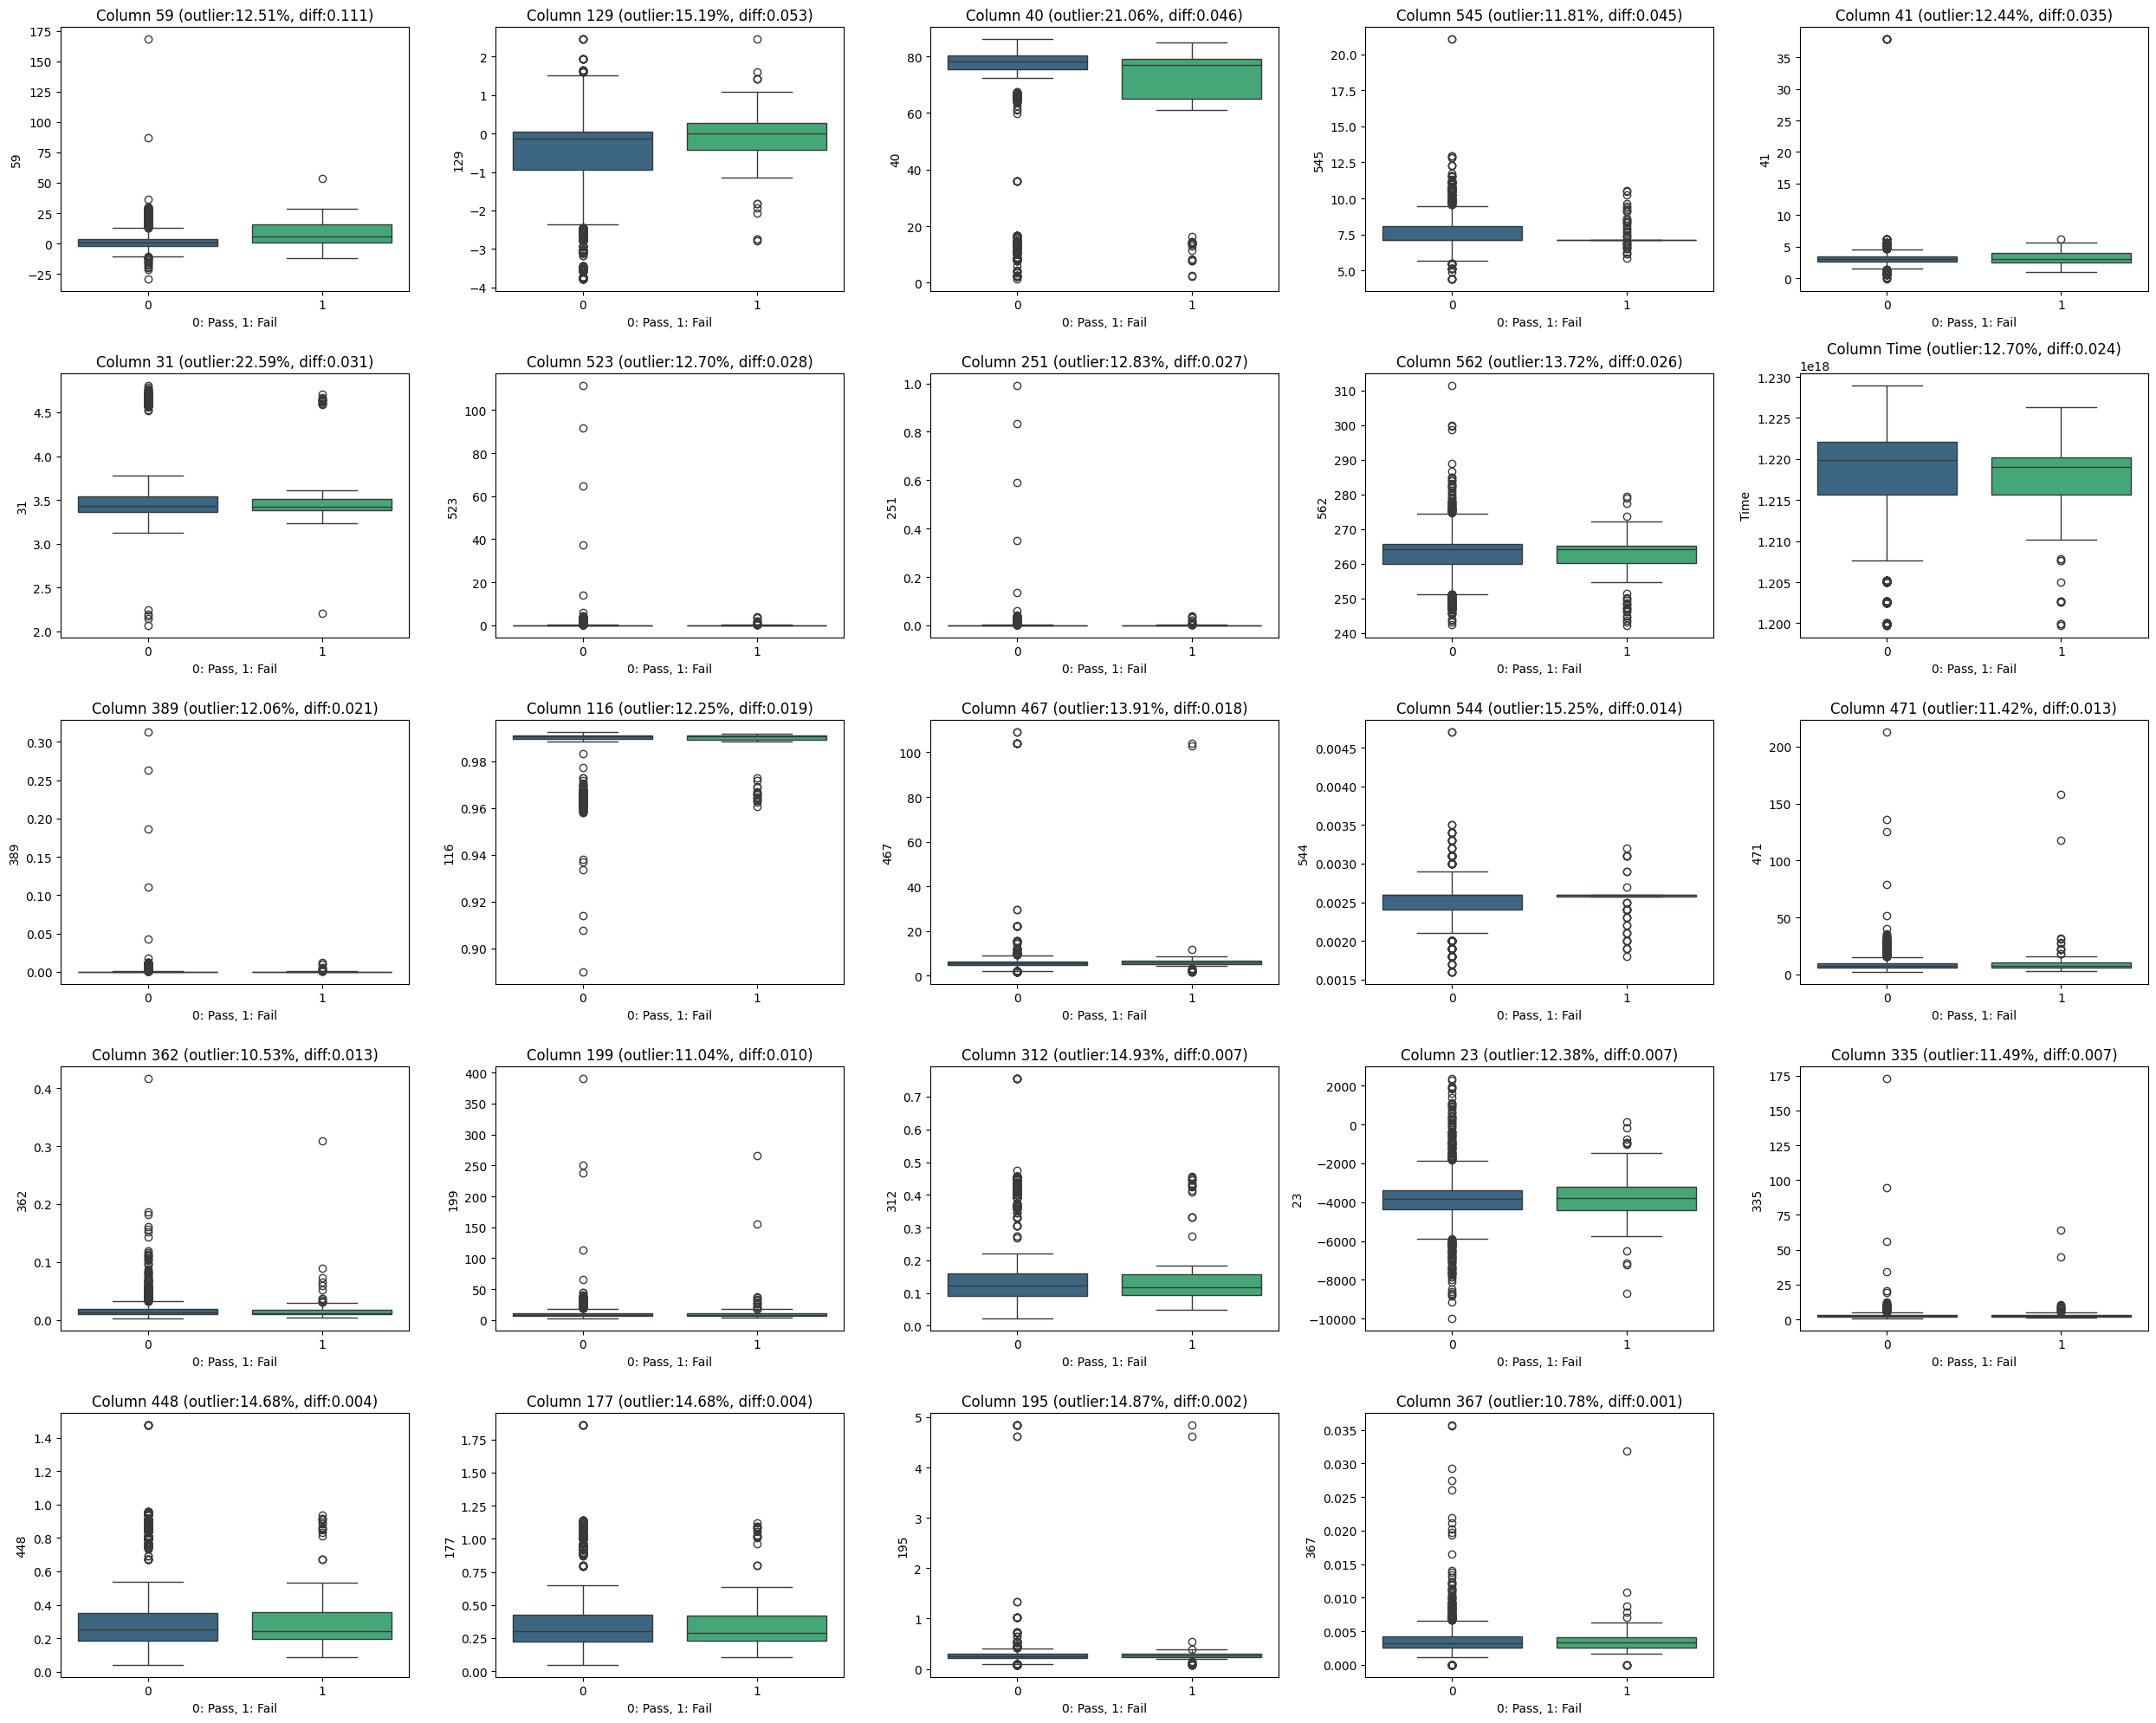

In [27]:
# 24개 colums 데이터 분포 시각화
fig, axes = plt.subplots(5, 5, figsize=(25, 20))
axes = axes.flatten()

for i, col in enumerate(high_outlier_cols):
    sns.boxplot(x=labels, y=my_data_dropped1[col], ax=axes[i], palette='viridis')
    axes[i].set_title(f"Column {col} (outlier:{outlier_result_df[outlier_result_df['column']==col]['outlier_ratio'].values[0]:.2%}, diff:{outlier_result_df[outlier_result_df['column']==col]['diff'].values[0]:.3f})")
    axes[i].set_xlabel("0: Pass, 1: Fail")

# 남은 칸 숨기기
for i in range(len(high_outlier_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [28]:
# 확인 결과, 59, 129, 40, Time 열이 시각적 차이 있음
# Time은 무시, 59열은 이미 Flagging 됨
# 129, 40 열 수동으로 추가

In [29]:
# 99셀에 flagging_cols += ['40', '129'] 추가
# Flagging 코드 수정 완료

In [30]:
# 현재, 불량 데이터 샘플 비율이 매우 적어, 제거 어려움.
# 클리핑 방식 사용 -> 이상치를 IQR 방식의 상한값 or 하한값으로 대체
# -> Flagging으로 정보 보존 했으므로, 클리핑 방식이 적절

In [31]:
# 각 열에 클리핑 방식 적용
data_clipped = final_data.copy()

for col in data_clipped.columns:
    # Pass/Fail과 flag 열은 클리핑 제외
    if col == 'Pass/Fail' or 'outlier_flag' in col:
        continue
    Q1 = data_clipped[col].quantile(0.25)
    Q3 = data_clipped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data_clipped[col] = data_clipped[col].clip(lower, upper)
    """clip(하한, 상한) -> 하한보다 작은 값은 하한값으로, 상한보다 큰 값은 상한값으로 대체"""

exclude_cols = ['Pass/Fail'] + [col for col in data_clipped.columns if 'outlier_flag' in col]

# 클리핑 전후 이상치 수 비교
before = final_data.drop(columns=exclude_cols).apply(
    lambda x: ((x < x.quantile(0.25) - 1.5*(x.quantile(0.75)-x.quantile(0.25))) | 
               (x > x.quantile(0.75) + 1.5*(x.quantile(0.75)-x.quantile(0.25)))).sum()).sum()

print(f"클리핑 전 이상치 수: {before}")
print(f"클리핑 후 이상치 수: {data_clipped.drop(columns=exclude_cols).apply(lambda x: ((x < x.quantile(0.25) - 1.5*(x.quantile(0.75)-x.quantile(0.25))) | 
                                                    (x > x.quantile(0.75) + 1.5*(x.quantile(0.75)-x.quantile(0.25)))).sum()).sum()}")

클리핑 전 이상치 수: 23888
클리핑 후 이상치 수: 0


In [32]:
# 이상치 대체 완료
# features 간 상관관계 확인 필요(중복 열 제거)

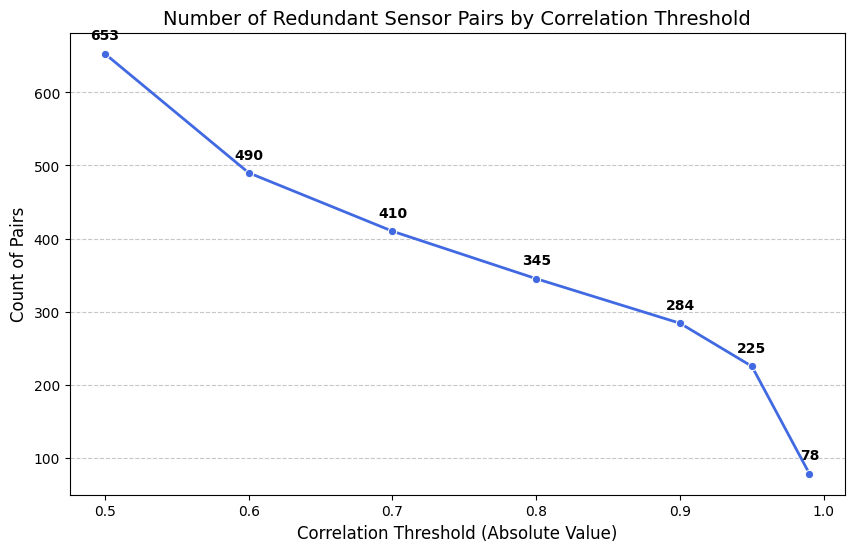

In [33]:
# 상관관계 행렬 계산
# Pass/Fail, 플래그와 센서 열 분리
protected_cols = ['Pass/Fail'] + [col for col in data_clipped.columns if 'outlier_flag' in col]
sensor_cols = [col for col in data_clipped.columns if col not in protected_cols]

# 센서 데이터에 대해서 상관관계 행렬 계산
sensor_corr = data_clipped[sensor_cols].corr().abs()
"""corr(): 모든 열 간의 상관관계를 행렬로 저장"""

# 3. 중복 제거를 위해 상삼각행렬(Upper Triangle)의 값만 추출
upper_tri = sensor_corr.where(np.triu(np.ones(sensor_corr.shape), k=1).astype(bool))
all_corrs = upper_tri.stack().reset_index()
all_corrs.columns = ['col1', 'col2', 'corr_value']

# 4. 구간(Threshold) 설정 및 개수 집계
thresholds = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
counts = []

for t in thresholds:
    count = (all_corrs['corr_value'] >= t).sum()
    counts.append(count)

# 5. 시각화
plt.figure(figsize=(10, 6))
sns.lineplot(x=thresholds, y=counts, marker='o', color='royalblue', linewidth=2)

# 각 점 위에 개수 표시 (Annotate)
for i, txt in enumerate(counts):
    plt.annotate(f'{txt}', (thresholds[i], counts[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, fontweight='bold')

plt.title("Number of Redundant Sensor Pairs by Correlation Threshold", fontsize=14)
plt.xlabel("Correlation Threshold (Absolute Value)", fontsize=12)
plt.ylabel("Count of Pairs", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

상관관계 0.95 이상: 225쌍
상관관계 0.96 이상: 184쌍
상관관계 0.97 이상: 152쌍
상관관계 0.98 이상: 124쌍
상관관계 0.99 이상: 78쌍


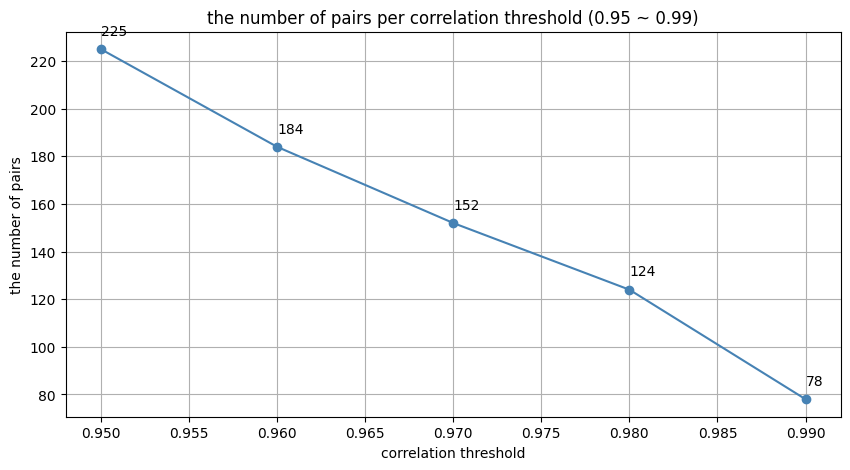

In [34]:
thresholds = [0.95, 0.96, 0.97, 0.98, 0.99]
counts_detail = []

for t in thresholds:
    count = 0
    for i in range(len(sensor_corr.columns)):
        for j in range(i+1, len(sensor_corr.columns)):
            if abs(sensor_corr.iloc[i, j]) >= t:
                count += 1
    counts_detail.append(count)
    print(f"상관관계 {t} 이상: {count}쌍")

plt.figure(figsize=(10, 5))
plt.plot(thresholds, counts_detail, marker='o', color='steelblue')
plt.title("the number of pairs per correlation threshold (0.95 ~ 0.99)")
plt.xlabel("correlation threshold")
plt.ylabel("the number of pairs")
for t, c in zip(thresholds, counts_detail):
    plt.annotate(f'{c}', (t, c), textcoords="offset points", xytext=(0, 10))
plt.grid(True)
plt.show()

In [35]:
# 조사 결과, 0.95까지는 완만하게 감소하다가, 0.99에서 급격히 감소하는 elbow 확인
# 0.95에서 0.99사이에 elbow가 보이지 않음.
# 상관관계 중복 제거의 기준을 0.95하는 것이 합리적.

In [36]:
# 상관관계가 0.95 이상인 쌍 시각적 확인

# 플래그와 Pass/Fail 열은 보호
protected_cols = ['Pass/Fail'] + [col for col in data_clipped.columns if 'outlier_flag' in col]
sensor_cols = [col for col in data_clipped.columns if col not in protected_cols]

# 센서 데이터들 사이에서만 상관관계 행렬 생성
sensor_corr = data_clipped[sensor_cols].corr()

high_corr_pairs = []
cols = sensor_corr.columns

"""j를 i+1부터 시작하게 해, 중복되는 관계, 동일 열 간 관계 확인 안 함"""
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        # 2. corr_matrix 대신 sensor_corr 사용 (절댓값 기준)
        if abs(sensor_corr.iloc[i, j]) >= 0.95: 
            high_corr_pairs.append({
                'col1': cols[i],
                'col2': cols[j],
                'correlation': sensor_corr.iloc[i, j]
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('correlation', ascending=False)
print(f"상관관계 0.95 이상 쌍 개수: {len(high_corr_df)}")
print(high_corr_df.head(20))

상관관계 0.95 이상 쌍 개수: 225
    col1 col2  correlation
64   172  174     1.000000
174  307  309     0.999999
147  254  526     0.999977
35   153  426     0.999933
126  222  494     0.999930
23   147  420     0.999899
78   176  447     0.999887
40   155  428     0.999872
153  268  540     0.999837
137  248  520     0.999739
220  572  576     0.999718
42   156  429     0.999695
223  583  585     0.999678
76   175  446     0.999454
80   177  448     0.999420
83   181  453     0.999174
145  253  525     0.999107
27   148  421     0.998916
124  221  493     0.998905
39   154  427     0.998851


In [37]:
# 상관관계가 0.95이상인 쌍에서 col2만 제거 대상으로 하여 추출
cols_to_remove = set(high_corr_df['col2'].tolist())
print(f"제거할 열 개수: {len(cols_to_remove)}")

data_cleaned = data_clipped.drop(columns=cols_to_remove)
print(f"제거 전 열 개수: {data_clipped.shape[1]}")
print(f"제거 후 열 개수: {data_cleaned.shape[1]}")

# Pass/Fail 열 분리
# Pass/Fail은 label이지 피처가 아니기때문에 모델링 단계에서 입력 데이터(X)와 정답(y)을 분리해야 하므로 지금 제거
y = data_cleaned['Pass/Fail']
X = data_cleaned.drop(columns=['Pass/Fail'])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

제거할 열 개수: 161
제거 전 열 개수: 525
제거 후 열 개수: 364
X shape: (1567, 363)
y shape: (1567,)


정상(-1): 1463개 (93.4%)
불량( 1): 104개 (6.6%)


/tmp/ipykernel_17/1630505669.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis', ax=axes[0])


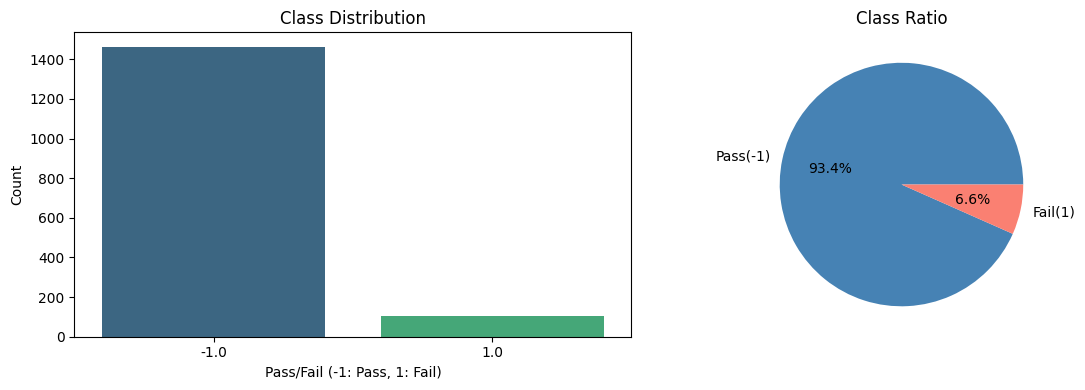

In [38]:
# 클래스 불균형 확인
class_counts = y.value_counts()
class_ratio = y.value_counts(normalize=True) * 100

print(f"정상(-1): {class_counts[-1]}개 ({class_ratio[-1]:.1f}%)")
print(f"불량( 1): {class_counts[1]}개 ({class_ratio[1]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=y, palette='viridis', ax=axes[0])
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Pass/Fail (-1: Pass, 1: Fail)")
axes[0].set_ylabel("Count")

axes[1].pie(class_counts, labels=['Pass(-1)', 'Fail(1)'], autopct='%1.1f%%', colors=['steelblue', 'salmon'])
axes[1].set_title("Class Ratio")

plt.tight_layout()
plt.show()

In [39]:
# Pass/Fail과 features간 상관관계 파악 필요
# MI방식 사용이 가장 적합해 보임
# because 비선형 관계 포착 가능 / 클래스 불균형에 강함

Pass/Fail과 MI 상위 80개 피처:
Time               0.030946
33                 0.023785
577                0.022408
570                0.022241
571                0.021248
                     ...   
84                 0.010329
55_outlier_flag    0.010248
21                 0.010155
139                0.010149
32                 0.010089
Length: 80, dtype: float64


/tmp/ipykernel_17/1124708694.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_df.head(80).values, y=mi_df.head(80).index, palette='viridis')


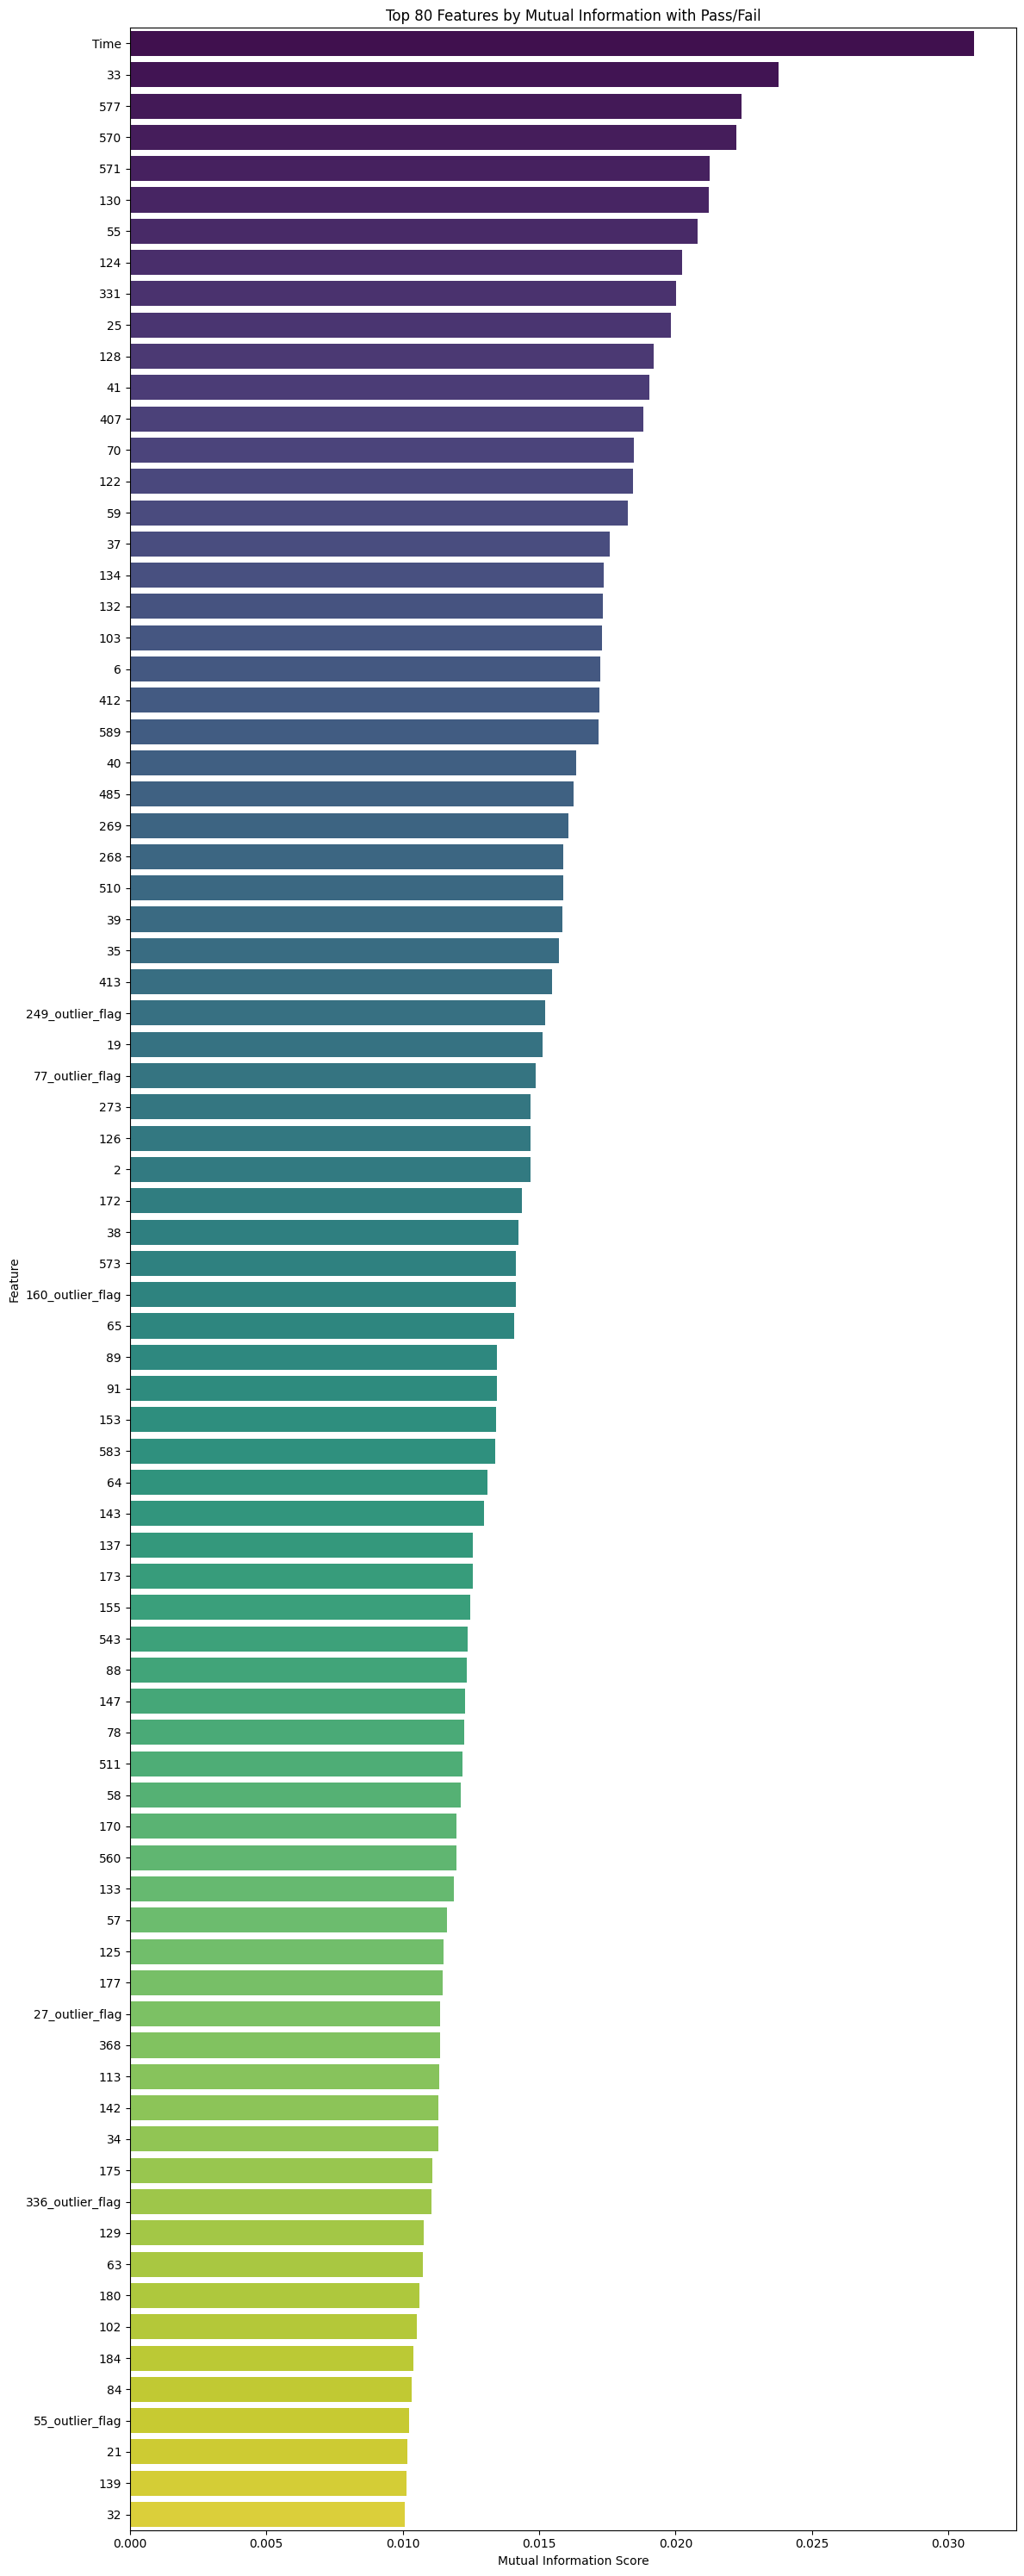

In [40]:
from sklearn.feature_selection import mutual_info_classif

# Mutual Information 계산
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("Pass/Fail과 MI 상위 80개 피처:")
print(mi_df.head(80))

# 시각화
plt.figure(figsize=(12, 30))
sns.barplot(x=mi_df.head(80).values, y=mi_df.head(80).index, palette='viridis')
plt.title("Top 80 Features by Mutual Information with Pass/Fail")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [41]:
# flag 열만 따로 확인
flag_mi = mi_df[mi_df.index.str.contains('outlier_flag')].head(10)
print(flag_mi)

249_outlier_flag    0.015209
77_outlier_flag     0.014888
160_outlier_flag    0.014139
27_outlier_flag     0.011369
336_outlier_flag    0.011052
55_outlier_flag     0.010248
477_outlier_flag    0.009586
479_outlier_flag    0.009120
38_outlier_flag     0.008972
385_outlier_flag    0.007992
dtype: float64


In [42]:
# MI값이 전반적으로 낮음: 여러 센서의 복합적인 영향으로 불량이 발생했다고 추측 가능
# Time 값이 1위: 장비 노후화나 공정 드리프트 등 특정 시간대 패턴일 가능성
# Flag 열도 MI 값이 낮음
# 30~50번대, 120번대, 570번대에 집중 -> 특정 공정의 불량일 수 있음
# 플래깅한 129번과 인접한 128번의 값이 2위 -> 핵심 변수일 수 있음

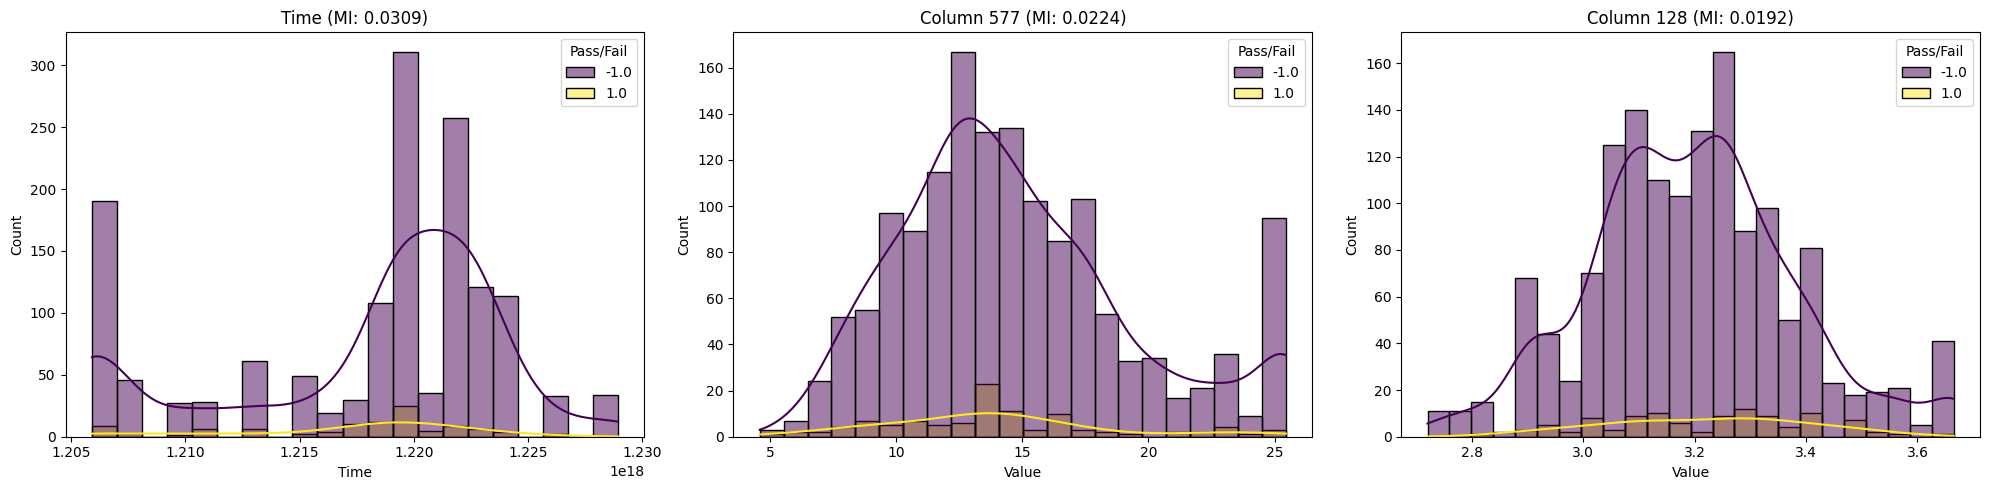

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Time - 시간 흐름에 따른 불량 분포
sns.histplot(data=X, x='Time', hue=y, kde=True, ax=axes[0], palette='viridis')
axes[0].set_title(f"Time (MI: {mi_df['Time']:.4f})")
axes[0].set_xlabel("Time")

# 577
sns.histplot(data=X, x='577', hue=y, kde=True, ax=axes[1], palette='viridis')
axes[1].set_title(f"Column 577 (MI: {mi_df['577']:.4f})")
axes[1].set_xlabel("Value")

# 128
sns.histplot(data=X, x='128', hue=y, kde=True, ax=axes[2], palette='viridis')
axes[2].set_title(f"Column 128 (MI: {mi_df['128']:.4f})")
axes[2].set_xlabel("Value")

plt.tight_layout()
plt.show()

In [44]:
# Pass와 Fail의 분포가 거의 겹침 -> 단변수로는 안 됨
# 모든 열을 전수 조사는 불가능 -> 피처 선택 필요 -> 과적합 방지, 해석력 확보, 계산 효율성 및 중복성 제거

# 추가 조사 결과, top 80 MI plot에서 elbow가 안 보임

# Baseline: 일단 Top 50으로 모델링
# 성능이 만족스럽지 않다면, 그래프가 완만한 것을 근거로 Top 80까지 확장해서 성능 변화를 비교
# Time이 압도적, 실제 장비 문제인지 단순 시간 순서대로 쌓인 데이터의 특징인지 모델 결과로 검증 필요

In [45]:
# MI 상위 50개 피처 이름 추출
top_50_cols = mi_df.head(50).index.tolist()

# 상위 50개 피처만 사용한 데이터셋 생성
X_selected = X[top_50_cols]

/tmp/ipykernel_17/838208123.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Sensor', data=feature_imp_df.head(20), palette='rocket')


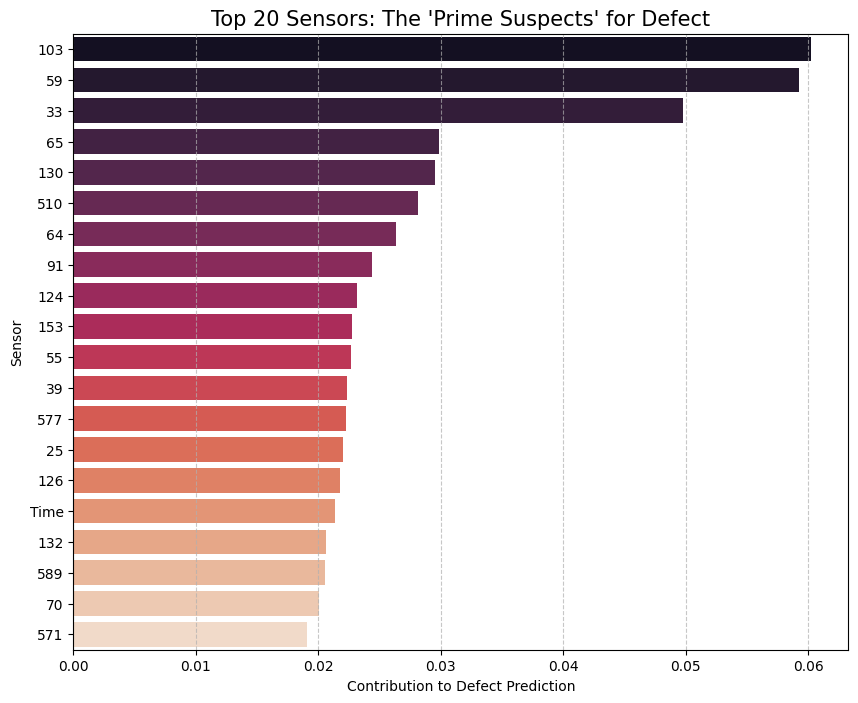

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 데이터 분할 (불량 비율 6.6% 유지)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

# 모델 생성 및 학습 (불량에 집중)
rf_model = RandomForestClassifier(
    n_estimators=200,         # 나무 200개 더 정밀하게 조사
    max_depth=15,             # 과적합 방지
    class_weight='balanced',  
    random_state=42
)
rf_model.fit(X_train, y_train)

# 불량 원인 후보 리스트(Feature Importance) 추출
importances = rf_model.feature_importances_
feature_names = X_selected.columns
feature_imp_df = pd.DataFrame({'Sensor': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# 상위 20개 범인 후보 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Sensor', data=feature_imp_df.head(20), palette='rocket')
plt.title("Top 20 Sensors: The 'Prime Suspects' for Defect", fontsize=15)
plt.xlabel("Contribution to Defect Prediction")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [47]:
# MI와 달리, 103번과 59번이 압도적이며, 33번은 MI와 모델에서도 상위권
# 103번과 59번이 다른 columns과 조합되어 불량을 일으키는 결정적 요인일 수 있음
# MI와 달리, Time의 순위 낮음 -> Time외 columns들이 진짜 원인임

# 상위 센서들이 정상일때와 불량일 때 데이터가 어떻게 다른지 확인 필요

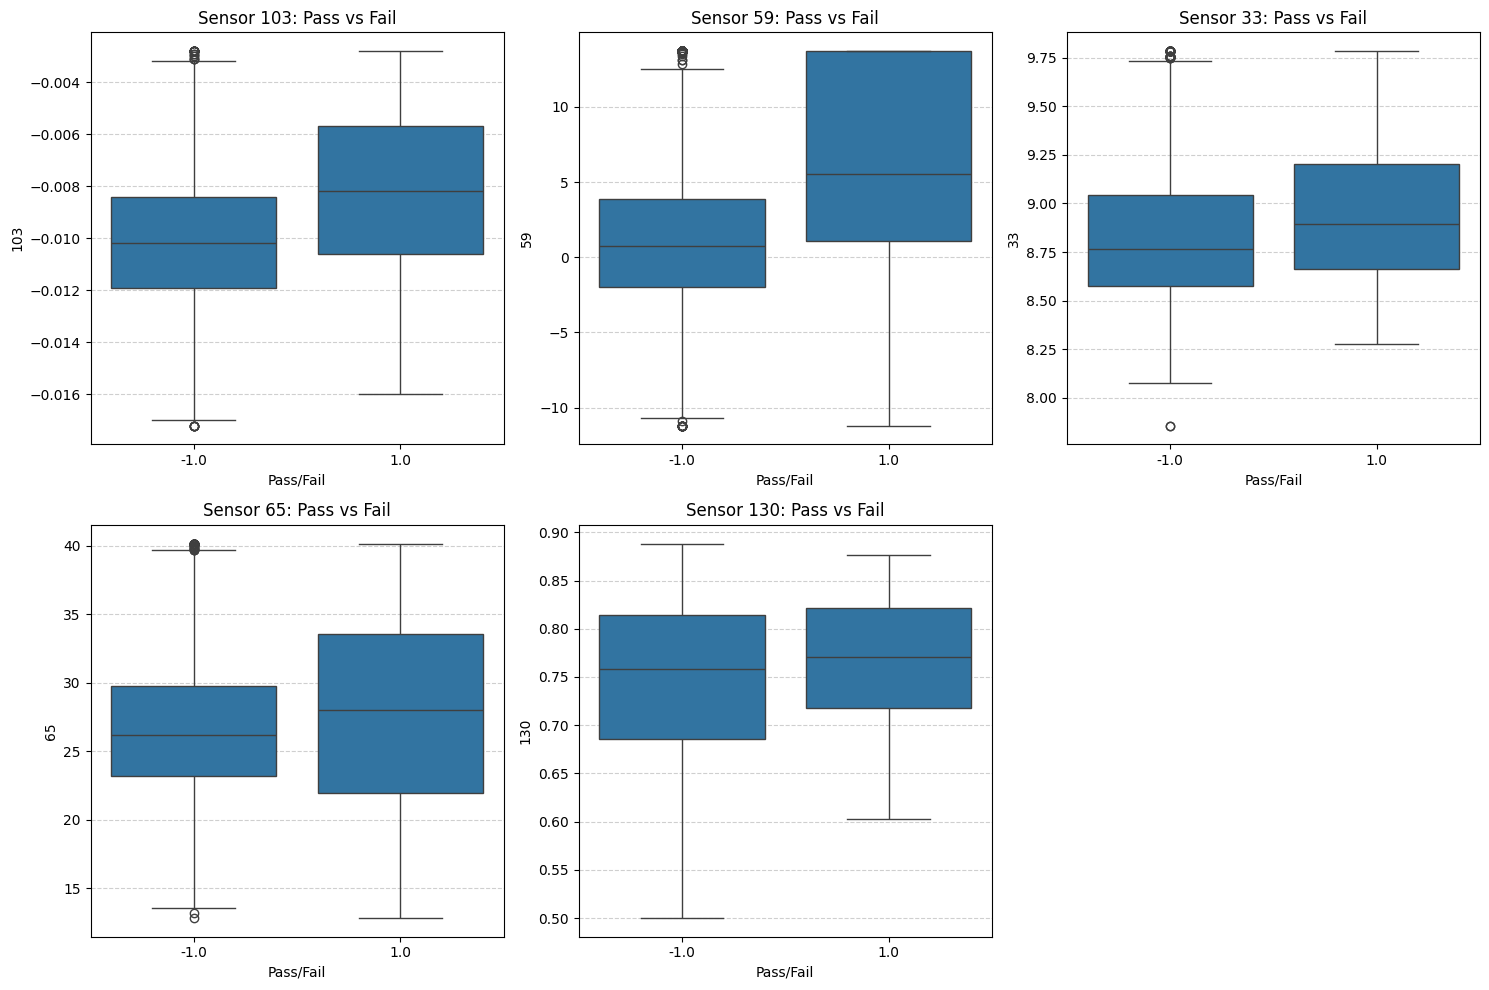

In [48]:
# 모델 Top 5 원인 후보
top_suspects = ['103', '59', '33', '65', '130']

plt.figure(figsize=(15, 10))

for i, sensor in enumerate(top_suspects):
    plt.subplot(2, 3, i+1)
    # Pass/Fail에 따른 수치 분포 비교
    sns.boxplot(x=y, y=X_selected[sensor])
    plt.title(f"Sensor {sensor}: Pass vs Fail")
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [49]:
# 59번: 분포 차이가 가장 극적으로 나타남. 가장 확정적인 주요 원인으로 보임.
# 103번: 불량일때 정상보다 전체적으로 위쪽으로 이동함.
# 나머지: 분포 차이가 있긴 하지만, 59번과 103번에 비해 박스가 꽤 겹침 -> 주요 원인보다는 보조적 원인으로 보임.

# 플래그열이 순위에 없음 -> 이상치 유무보다, 분포 자체가 변하는 상황이 불량에 더 핵심적임

--- [최종 모델 성능 보고서] ---
              precision    recall  f1-score   support

    Pass(-1)       0.93      1.00      0.97       293
     Fail(1)       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


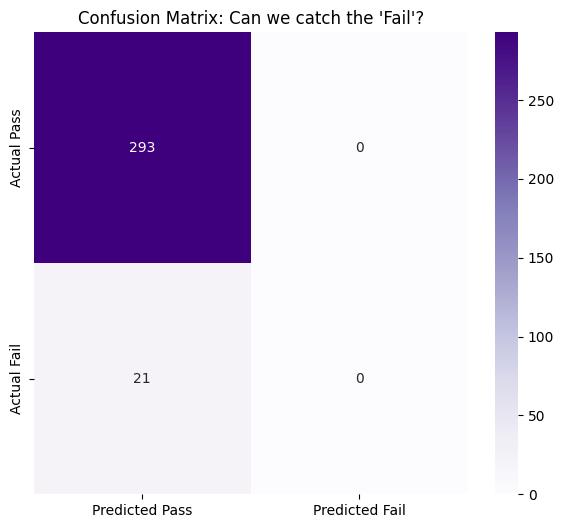

In [50]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# 테스트 데이터로 예측 수행
y_pred = rf_model.predict(X_test)

# 성능 보고서 출력
print("--- [최종 모델 성능 보고서] ---")
print(classification_report(y_test, y_pred, target_names=['Pass(-1)', 'Fail(1)']))

# 혼동 행렬(Confusion Matrix) 시각화
plt.figure(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Predicted Pass', 'Predicted Fail'],
            yticklabels=['Actual Pass', 'Actual Fail'])
plt.title("Confusion Matrix: Can we catch the 'Fail'?")
plt.show()

In [51]:
# 불량 예측 전혀 안 됨 -> 가중치, 임계값 조정 필요.

--- [임계값 0.15 적용 후 성능 보고서] ---
              precision    recall  f1-score   support

        -1.0       0.95      0.96      0.95       293
         1.0       0.28      0.24      0.26        21

    accuracy                           0.91       314
   macro avg       0.61      0.60      0.60       314
weighted avg       0.90      0.91      0.90       314



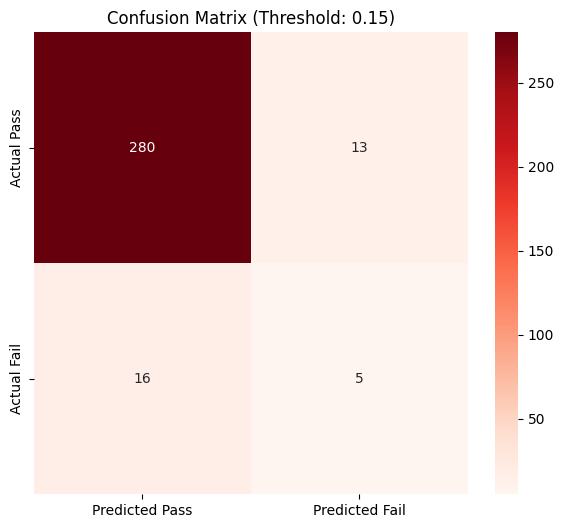

In [52]:
# 모델 가중치를 더 극단적으로 부여 (불량에 15배 가중치)
rf_model_v2 = RandomForestClassifier(
    n_estimators=200,
    class_weight={-1: 1, 1: 15}, # 불량을 15배 더 중요하게 취급
    random_state=42
)
rf_model_v2.fit(X_train, y_train)

# 단순히 예측(predict)하지 말고 확률(probability)을 가져오기
# [:, 1]은 '불량(1)일 확률'만 가져오겠다는 뜻.
y_probs = rf_model_v2.predict_proba(X_test)[:, 1] 

# 임계값 조정: 확률 0.15(15%)
threshold = 0.15
y_pred_new = np.where(y_probs > threshold, 1, -1)

# 결과 확인 (Confusion Matrix & Report)
print(f"--- [임계값 {threshold} 적용 후 성능 보고서] ---")
print(classification_report(y_test, y_pred_new))

plt.figure(figsize=(7, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_new), annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Pass', 'Predicted Fail'],
            yticklabels=['Actual Pass', 'Actual Fail'])
plt.title(f"Confusion Matrix (Threshold: {threshold})")
plt.show()

In [53]:
# 불량 잡아내기 시작. 불량 주요 원인 리스트 재추출

/tmp/ipykernel_17/2498794335.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Sensor', data=feature_imp_v2.head(20), palette='viridis')


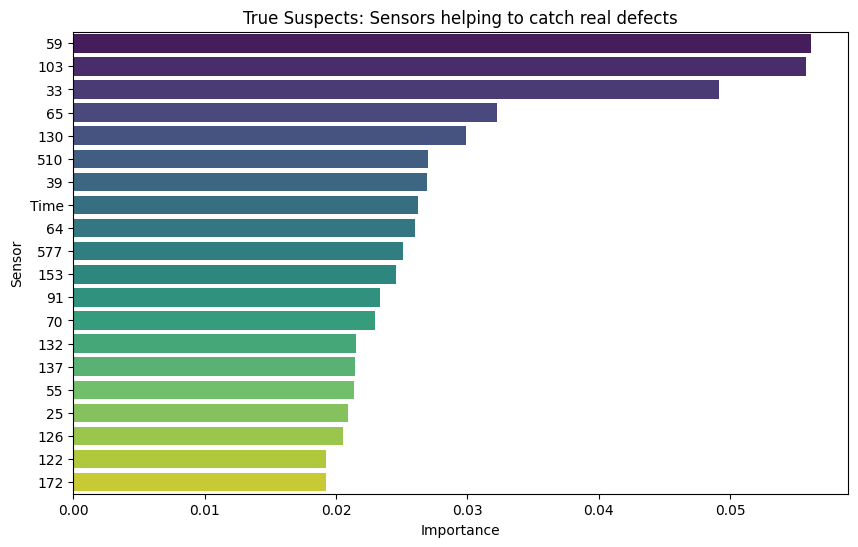

In [54]:
# 새 모델(rf_model_v2)에서 피처 중요도 다시 추출
importances_v2 = rf_model_v2.feature_importances_
feature_imp_v2 = pd.DataFrame({'Sensor': X_selected.columns, 'Importance': importances_v2})
feature_imp_v2 = feature_imp_v2.sort_values(by='Importance', ascending=False)

# 상위 20개 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Sensor', data=feature_imp_v2.head(20), palette='viridis')
plt.title("True Suspects: Sensors helping to catch real defects")
plt.show()

In [55]:
# Fail 데이터 부족 -> 훈련량 증가 필요, SMOTE 방식 적용 필요

증폭 전 불량 개수: 83
증폭 후 불량 개수: 1170

--- [SMOTE + Tuning 적용 후 성능] ---
              precision    recall  f1-score   support

        -1.0       0.99      0.60      0.75       293
         1.0       0.14      0.90      0.24        21

    accuracy                           0.62       314
   macro avg       0.56      0.75      0.49       314
weighted avg       0.93      0.62      0.71       314



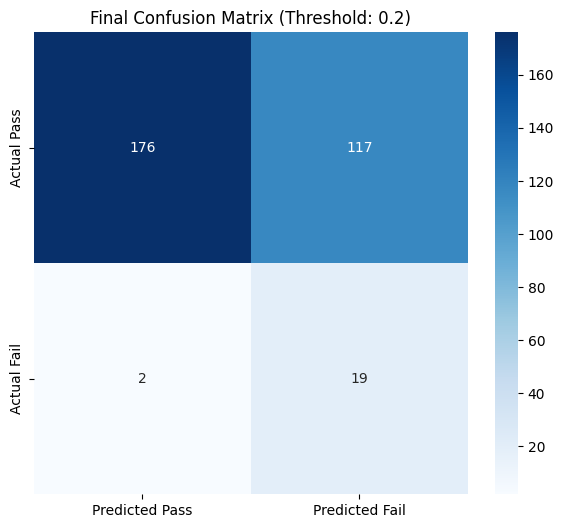

In [56]:
# SMOTE 기법으로 불량 데이터를 늘려 훈련 증가
!pip install imbalanced-learn

from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix

# SMOTE로 데이터 증폭 (불량 데이터를 정상 데이터 개수와 맞춤)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"증폭 전 불량 개수: {sum(y_train==1)}")
print(f"증폭 후 불량 개수: {sum(y_train_res==1)}")

# 업그레이드된 랜덤 포레스트 학습
# 불량 데이터가 많아졌으니 가중치(class_weight) 뺌
rf_final = RandomForestClassifier(
    n_estimators=300,      # 나무를 더 많이(안정성)
    max_depth=12,          # 과적합 방지
    min_samples_split=5,   # 가지치기 규칙 강화
    random_state=42
)
rf_final.fit(X_train_res, y_train_res)

# 최적의 임계값(Threshold) 찾기 (0.1 ~ 0.5 사이 탐색)
y_probs_final = rf_final.predict_proba(X_test)[:, 1]

# 0.2를 기준으로 먼저 확인
threshold = 0.2
y_pred_final = np.where(y_probs_final > threshold, 1, -1)

# 결과 출력
print(f"\n--- [SMOTE + Tuning 적용 후 성능] ---")
print(classification_report(y_test, y_pred_final))

# 혼동 행렬 시각화
plt.figure(figsize=(7, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Pass', 'Predicted Fail'],
            yticklabels=['Actual Pass', 'Actual Fail'])
plt.title(f"Final Confusion Matrix (Threshold: {threshold})")
plt.show()

In [57]:
# Recall(1.0): 0.90 -> 검거율 높음. 
# Precision(1.0): 0.14 -> 조사 과잉 . 모델이 100번 불량이라 하면 그중 14번만 진짜 불량
# Accuracy: 0.62 -> 낮음. 하지만 "정상"을 "불량"이라 오해해서 낮은 거라 치명적이진 않음.

# 수율방어적 관점에서는 괜찮지만, 엔지니어 관점에서는 매우 피곤한 결과임
# 임계값을 너무 낮게 설정해서 모델이 매우 예민 -> 임계값 조절 필요

In [58]:
# 임계값 테스트
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    y_pred_t = np.where(y_probs_final > t, 1, -1)
    rec = classification_report(y_test, y_pred_t, output_dict=True)['1.0']['recall']
    pre = classification_report(y_test, y_pred_t, output_dict=True)['1.0']['precision']
    print(f"임계값 {t:.1f} >> 재현율(Recall): {rec:.2f}, 정밀도(Precision): {pre:.2f}")

임계값 0.2 >> 재현율(Recall): 0.90, 정밀도(Precision): 0.14
임계값 0.3 >> 재현율(Recall): 0.48, 정밀도(Precision): 0.16
임계값 0.4 >> 재현율(Recall): 0.19, 정밀도(Precision): 0.18
임계값 0.5 >> 재현율(Recall): 0.19, 정밀도(Precision): 0.44
임계값 0.6 >> 재현율(Recall): 0.05, 정밀도(Precision): 0.33


In [59]:
# 0.3에서 재현율이 급격히 감소하지만, 정밀도는 조금 상승 -> 가성이 떨어짐
# 0.2와 0.3 사이 구간 더 조사 필요

In [60]:
# 0.2 ~ 0.3 구간 정밀 탐색
fine_thresholds = [0.2, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3]

for t in fine_thresholds:
    y_pred_t = np.where(y_probs_final > t, 1, -1)
    res = classification_report(y_test, y_pred_t, output_dict=True)['1.0']
    print(f"임계값 {t:.2f} >> Recall: {res['recall']:.2f}, Precision: {res['precision']:.2f}, F1: {res['f1-score']:.2f}")

임계값 0.20 >> Recall: 0.90, Precision: 0.14, F1: 0.24
임계값 0.21 >> Recall: 0.86, Precision: 0.14, F1: 0.25
임계값 0.22 >> Recall: 0.81, Precision: 0.15, F1: 0.25
임계값 0.23 >> Recall: 0.81, Precision: 0.16, F1: 0.27
임계값 0.24 >> Recall: 0.76, Precision: 0.16, F1: 0.26
임계값 0.25 >> Recall: 0.62, Precision: 0.14, F1: 0.23
임계값 0.26 >> Recall: 0.62, Precision: 0.15, F1: 0.24
임계값 0.27 >> Recall: 0.62, Precision: 0.16, F1: 0.26
임계값 0.28 >> Recall: 0.52, Precision: 0.15, F1: 0.23
임계값 0.29 >> Recall: 0.48, Precision: 0.15, F1: 0.23
임계값 0.30 >> Recall: 0.48, Precision: 0.16, F1: 0.24


In [61]:
# 0.23가 가장 효율적: 재현율 81%, F1-score 가장 높음(재현율과 정밀도 조화가 가장 좋음)

In [62]:
# 모델을 컴퓨터에 저장
import joblib

model_data = {
    'model': rf_final,
    'top_50_cols': top_50_cols,
    'threshold': 0.23
}

joblib.dump(model_data, 'semicon_defect_model_v1.joblib')
print("모델 저장 완료")

모델 저장 완료


In [63]:
# 새로운 데이터 모델로 예측하는 코드
"""import joblib
import numpy as np

# 저장된 모델 데이터 불러오기
loaded_data = joblib.load('semicon_defect_model_v1.joblib')
my_model = loaded_data['model']
target_cols = loaded_data['top_50_cols']
best_threshold = loaded_data['threshold']

# 새로운 데이터 준비 (원본 데이터에서 우리가 썼던 50개 피처만 뽑아야 함)
# X_new = new_df[target_cols] 

# 예측하기 (확률 기반)
new_probs = my_model.predict_proba(X_new)[:, 1]
new_preds = np.where(new_probs > best_threshold, 1, -1)

print("불량 예측 완료")"""
# 주의사항
# top_50_col과 새 데이터의 culumns 순서가 완전히 일치해야함
# 스케일링, 결측치 대체 등 전처리도 똑같은 기준으로 되어야함

'import joblib\nimport numpy as np\n\n# 저장된 모델 데이터 불러오기\nloaded_data = joblib.load(\'semicon_defect_model_v1.joblib\')\nmy_model = loaded_data[\'model\']\ntarget_cols = loaded_data[\'top_50_cols\']\nbest_threshold = loaded_data[\'threshold\']\n\n# 새로운 데이터 준비 (원본 데이터에서 우리가 썼던 50개 피처만 뽑아야 함)\n# X_new = new_df[target_cols] \n\n# 예측하기 (확률 기반)\nnew_probs = my_model.predict_proba(X_new)[:, 1]\nnew_preds = np.where(new_probs > best_threshold, 1, -1)\n\nprint("불량 예측 완료")'

In [64]:
def predict_defect(new_data):
    """
    새로운 데이터를 넣으면 전처리부터 불량 판정까지 한 번에 해주는 함수
    """
    # 모델과 피처 리스트 불러오기
    loaded = joblib.load('/kaggle/working/semicon_defect_model_v1.joblib')
    model = loaded['model']
    target_cols = loaded['top_50_cols']
    threshold = loaded['threshold']
    
    # 데이터 정렬 (학습할 때 썼던 50개 컬럼만, 그 순서대로 뽑기)
    # 만약 새 데이터에 없는 컬럼이 있다면 에러 방지를 위해 체크
    existing_cols = [c for c in target_cols if c in new_data.columns]
    X_processed = new_data[existing_cols]
    
    # 모델 예측 (확률값 추출)
    probs = model.predict_proba(X_processed)[:, 1]
    
    # 임계값(0.23) 적용해서 최종 판정
    preds = np.where(probs > threshold, "불량(Fail)", "정상(Pass)")
    
    return preds, probs

# --- 사용 예시 ---
# test_samples = df_raw.sample(5) # 샘플 데이터 5개 뽑기
# result_labels, result_probs = predict_defect(test_samples)
# print(result_labels)

In [65]:
# Conclusion
# 1. 모델링 및 정확도: 가장 효율적인 모델 추려냄
# 2. 주요 원인 센서: 59번(불량시 변동폭 매우 커짐 -> 핵심 지표), 103번(불량시 수치 상향 -> 공정 파라미터의 드리프트 의심됨), 33번(꾸준히 통계적으로 연관성 있음, 다른 센서등과 결합해 불량 유도)

In [66]:
# 실시간 감시 프로그램 (FDC) / 이 셀과, 'semicon_defect_model_v1.joblib'파일만 복사해서 사용하면 구현됨

import time
import pandas as pd
import numpy as np
import joblib
import os
from datetime import datetime

# 환경 설정 (모델 파일 및 로그 경로)
MODEL_FILE = 'semicon_defect_model_v1.joblib'
LOG_FILE = 'realtime_production_log.csv'

def start_realtime_monitoring():
    print("실시간 공정 감시 시스템 시작")
    
    # [준비] 모델 패키지 로드 (없으면 생성)
    if not os.path.exists(MODEL_FILE):
        joblib.dump({'model': rf_final, 'top_50_cols': top_50_cols, 'threshold': 0.23}, MODEL_FILE)
    
    loaded = joblib.load(MODEL_FILE)
    model, target_cols, threshold = loaded['model'], loaded['top_50_cols'], loaded['threshold']

    # [자동화 루프] 시스템이 종료될 때까지 무한 반복
    try:
        while True:
            # [입력] 실시간 센서 데이터 가져오기 
            # (실제는 DB 쿼리나 API 호출 코드가 들어감. 여기선 X_test의 한 샘플을 예시로 사용)
            # current_sensor_data = get_latest_sensor_data() 
            current_sensor_data = X_test.sample(1) # 예시용: 테스트 데이터에서 무작위 1건 추출
            
            # [분석] 모델 추론
            X_processed = current_sensor_data[target_cols]
            prob = model.predict_proba(X_processed)[0, 1]
            result = "Fail" if prob > threshold else "Pass"
            
            # [출력] 실시간 결과 리포트
            now = datetime.now().strftime('%H:%M:%S')
            if result == "Fail":
                print(f"[{now}] [비상] 불량 감지 | 확률: {prob:.2%} | 즉시 조치 요망")
            else:
                print(f"[{now}] [정상] | (확률: {prob:.2%})")
            
            # [정리] 데이터 로깅 (기록 보존)
            log_data = pd.DataFrame([{
                'time': now,
                'prob': prob,
                'result': result
            }])
            log_data.to_csv(LOG_FILE, mode='a', header=not os.path.exists(LOG_FILE), index=False)
            
            # [대기] 센서 수집 주기 설정 (예: 1초마다 확인)
            time.sleep(1)

    except KeyboardInterrupt:
        print("\n시스템 종료")

# 시스템 가동
# start_realtime_monitoring()